# ¿Existe una asociación significativa entre el nivel de actividad física y el IMC como predictores del riesgo de diabetes?

**Autora:** Sandy Alonso

Este proyecto analiza un dataset de 15,000 pacientes en India para explorar cómo el nivel de actividad física y el índice de masa corporal (IMC) se relacionan con el riesgo de diabetes. El objetivo es identificar patrones que puedan orientar recomendaciones de prevención basadas en hábitos de vida

In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv('../data/raw/diabetes_risk.csv')

## Descripción de las columnas del dataset

El dataset contiene 15,000 pacientes de distintas ciudades de India, con 19 columnas:

- `patient_id`: identificador único del paciente.
- `age`: edad del paciente en años.
- `gender`: género (Female, Male, Other).
- `city`: ciudad de residencia.
- `bmi`: índice de masa corporal.
- `family_history_diabetes`: si tiene antecedentes familiares de diabetes (Yes, No).
- `physical_activity_level`: nivel de actividad física (Sedentary, Moderate, Active).
- `diet_type`: tipo de dieta (Vegetarian, Non-Vegetarian, Pescatarian, Vegan).
- `smoking_status`: estatus de tabaquismo (Never, Current, Former).
- `alcohol_consumption`: consumo de alcohol (Never, Occasional, Regular).
- `hours_sleep_per_night`: horas de sueño por noche.
- `stress_level`: nivel de estrés autorreportado, en una escala de 1 a 10.
- `fasting_blood_sugar`: glucosa en ayuno.
- `hba1c_level`: nivel de hemoglobina glucosilada (HbA1c).
- `blood_pressure_systolic`: presión arterial sistólica.
- `blood_pressure_diastolic`: presión arterial diastólica.
- `waist_circumference_cm`: circunferencia de cintura en centímetros.
- `income_bracket`: nivel de ingresos (Low, Middle, High).
- `diabetes_risk`: variable objetivo, riesgo de diabetes (Low, Moderate, High).

## Preguntas que guían el análisis

1. ¿El nivel de actividad física está asociado con el riesgo de diabetes?
2. ¿El IMC difiere entre los niveles de riesgo de diabetes?
3. ¿El IMC difiere según el nivel de actividad física?
4. ¿La relación entre IMC y riesgo se mantiene dentro de cada nivel de actividad física?
5. ¿Qué otros factores (historial familiar, género, dieta, tabaquismo) se asocian con el riesgo?

## Paso 1: Carga de datos y vista rápida

### 1.1. Head y Tail del Dataset

In [3]:
print("Head of DataFrame:")
print(df.head())

Head of DataFrame:
   patient_id  age  gender       city   bmi family_history_diabetes  \
0           1   47  Female     Mumbai  26.5                     Yes   
1           2   53  Female     Mumbai  20.5                     Yes   
2           3   47    Male      Thane  31.3                      No   
3           4   41    Male  Bengaluru  22.8                      No   
4           5   57  Female  Bengaluru  16.7                      No   

  physical_activity_level       diet_type smoking_status alcohol_consumption  \
0               Sedentary      Vegetarian          Never               Never   
1                Moderate      Vegetarian          Never               Never   
2                Moderate  Non-Vegetarian        Current             Regular   
3               Sedentary  Non-Vegetarian          Never               Never   
4               Sedentary  Non-Vegetarian        Current          Occasional   

   hours_sleep_per_night  stress_level  fasting_blood_sugar  hba1c_level 

In [4]:
print("Tail of DataFrame:")
print(df.tail())

Tail of DataFrame:
       patient_id  age  gender       city   bmi family_history_diabetes  \
14995       14996   47    Male     Mumbai  37.7                      No   
14996       14997   48  Female     Mumbai  20.6                      No   
14997       14998   34  Female     Nagpur  17.9                      No   
14998       14999   56    Male  Ahmedabad  20.7                     Yes   
14999       15000   54    Male      Surat  34.5                      No   

      physical_activity_level       diet_type smoking_status  \
14995               Sedentary  Non-Vegetarian          Never   
14996                Moderate  Non-Vegetarian          Never   
14997                  Active      Vegetarian          Never   
14998                  Active      Vegetarian          Never   
14999                Moderate      Vegetarian          Never   

      alcohol_consumption  hours_sleep_per_night  stress_level  \
14995               Never                    6.8             7   
14996        

**Objetivo:**
Confirmar el tamaño del dataset y revisar la estructura general antes de avanzar al análisis de calidad de datos.

In [5]:
# forma del dataset
print(df.shape)

(15000, 19)


In [6]:
# información general: tipos de datos y nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  str    
 3   city                      15000 non-null  str    
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  str    
 6   physical_activity_level   15000 non-null  str    
 7   diet_type                 15000 non-null  str    
 8   smoking_status            14528 non-null  str    
 9   alcohol_consumption       11212 non-null  str    
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_pressure_sy

In [7]:
# tipos de datos por columna
print(df.dtypes)

patient_id                    int64
age                           int64
gender                          str
city                            str
bmi                         float64
family_history_diabetes         str
physical_activity_level         str
diet_type                       str
smoking_status                  str
alcohol_consumption             str
hours_sleep_per_night       float64
stress_level                  int64
fasting_blood_sugar           int64
hba1c_level                 float64
blood_pressure_systolic       int64
blood_pressure_diastolic      int64
waist_circumference_cm      float64
income_bracket                  str
diabetes_risk                   str
dtype: object


**Comentario:**
El dataset tiene 15,000 filas y 19 columnas. Hay columnas numéricas (edad, IMC, glucosa, HbA1c, presión, cintura, horas de sueño, estrés) y columnas categóricas tipo texto (género, ciudad, historial familiar, actividad física, dieta, tabaquismo, alcohol, ingreso, riesgo de diabetes). En la siguiente sección revisamos nulos, duplicados y valores sospechosos.

## Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**Objetivo:**
Cuantificar los valores nulos por columna, en conteo y en porcentaje.

In [8]:
# cantidad de nulos por columna
print(df.isna().sum())
print(df.isna().mean() * 100)

patient_id                     0
age                            0
gender                         0
city                           0
bmi                            0
family_history_diabetes        0
physical_activity_level        0
diet_type                      0
smoking_status               472
alcohol_consumption         3788
hours_sleep_per_night          0
stress_level                   0
fasting_blood_sugar            0
hba1c_level                    0
blood_pressure_systolic        0
blood_pressure_diastolic       0
waist_circumference_cm         0
income_bracket               463
diabetes_risk                  0
dtype: int64
patient_id                   0.000000
age                          0.000000
gender                       0.000000
city                         0.000000
bmi                          0.000000
family_history_diabetes      0.000000
physical_activity_level      0.000000
diet_type                    0.000000
smoking_status               3.146667
alcohol_consumptio

**Comentario:**
Solo tres columnas presentan nulos: `alcohol_consumption`, `smoking_status` e `income_bracket`. El resto de las columnas están completas. En la sección 2.4 revisamos si estos nulos dependen de otras variables.

### 2.2 Revisión de duplicados

**Objetivo:**
Verificar si existen filas completas duplicadas o pacientes repetidos por `patient_id`.

In [9]:
# duplicados: filas completas y por patient_id
print('Filas duplicadas:', df.duplicated().sum())
print('patient_id duplicados:', df['patient_id'].duplicated().sum())

Filas duplicadas: 0
patient_id duplicados: 0


**Comentario:**
No se encontraron filas duplicadas ni valores repetidos de `patient_id`. Cada paciente aparece una sola vez en el dataset.

### 2.3 Detección de valores inválidos y sentinels

**Objetivo:**
Revisar los rangos de las columnas numéricas y los valores únicos de las categóricas, para detectar valores fuera de lo clínicamente plausible o posibles sentinels.

In [10]:
# columnas numéricas
print(df.describe())

         patient_id           age           bmi  hours_sleep_per_night  \
count  15000.000000  15000.000000  15000.000000           15000.000000   
mean    7500.500000     44.333667     23.062260               7.309860   
std     4330.271354     10.383753      4.046391               1.109372   
min        1.000000     18.000000     15.000000               3.000000   
25%     3750.750000     38.000000     20.100000               6.700000   
50%     7500.500000     45.000000     22.700000               7.000000   
75%    11250.250000     52.000000     25.600000               8.000000   
max    15000.000000     80.000000     40.800000              12.000000   

       stress_level  fasting_blood_sugar   hba1c_level  \
count  15000.000000         15000.000000  15000.000000   
mean       5.941200           168.789933      6.878387   
std        2.148406            38.365822      0.843276   
min        1.000000            72.000000      4.800000   
25%        4.000000           145.000000   

**Insights:**
- `age`: va de 18 a 80 años, un rango razonable para el estudio.
- `bmi`: va de aproximadamente 15 a 41, dentro de valores clínicamente posibles.
- `fasting_blood_sugar`: llega hasta 400, un valor alto pero clínicamente posible en pacientes diabéticos sin control.
- `hba1c_level`: llega hasta 13.4, también alto pero plausible en diabetes descontrolada.
- `blood_pressure_systolic` y `blood_pressure_diastolic`: los máximos (200 y 120) son altos pero corresponden a crisis hipertensivas reales, no parecen errores de captura.
- `hours_sleep_per_night`: rango razonable, sin valores negativos ni extremos imposibles.
- `stress_level`: se mantiene dentro de la escala esperada de 1 a 10.
- `waist_circumference_cm`: va de 73.2 a 148.2, un rango amplio pero posible.

No se detectan valores imposibles (negativos, ceros donde no deberían, o fuera de escala). Los valores más altos son extremos clínicos, no sentinels.

In [11]:
# columnas categóricas
cat_cols = ['gender', 'city', 'family_history_diabetes', 'physical_activity_level',
            'diet_type', 'smoking_status', 'alcohol_consumption', 'income_bracket', 'diabetes_risk']
for col in cat_cols:
    print(col, df[col].unique())

gender <StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str
city <StringArray>
[       'Mumbai',         'Thane',     'Bengaluru',     'Hyderabad',
         'Delhi',       'Kolkata',     'Ahmedabad',          'Pune',
       'Chennai',        'Kanpur',        'Bhopal', 'Visakhapatnam',
         'Patna',        'Jaipur',         'Surat',        'Nagpur',
        'Indore',       'Lucknow']
Length: 18, dtype: str
family_history_diabetes <StringArray>
['Yes', 'No']
Length: 2, dtype: str
physical_activity_level <StringArray>
['Sedentary', 'Moderate', 'Active']
Length: 3, dtype: str
diet_type <StringArray>
['Vegetarian', 'Non-Vegetarian', 'Pescatarian', 'Vegan']
Length: 4, dtype: str
smoking_status <StringArray>
['Never', 'Current', nan, 'Former']
Length: 4, dtype: str
alcohol_consumption <StringArray>
['Never', 'Regular', 'Occasional', nan]
Length: 4, dtype: str
income_bracket <StringArray>
['High', 'Low', 'Middle', nan]
Length: 4, dtype: str


diabetes_risk <StringArray>
['Low', 'High', 'Moderate']
Length: 3, dtype: str


**Insights:**
Todas las columnas categóricas presentan categorías esperadas, sin valores sospechosos tipo '?', '-999' o similares. Los `nan` que aparecen en `smoking_status`, `alcohol_consumption` e `income_bracket` corresponden a los nulos ya identificados en 2.1, no a sentinels adicionales.

### 2.4 Mecanismo de los valores nulos

**Objetivo:**
Investigar si los nulos de `alcohol_consumption`, `smoking_status` e `income_bracket` dependen de otras variables (riesgo de diabetes, género, nivel de actividad física), para decidir si son MCAR (completamente al azar) o MAR (al azar condicionado a otra variable).

In [12]:
# indicadores de nulo por columna
df['alcohol_null'] = df['alcohol_consumption'].isna()
df['smoking_null'] = df['smoking_status'].isna()
df['income_null'] = df['income_bracket'].isna()

for null_col in ['alcohol_null', 'smoking_null', 'income_null']:
    for cat_col in ['diabetes_risk', 'gender', 'physical_activity_level']:
        tabla = pd.crosstab(df[null_col], df[cat_col])
        chi2, p, dof, exp = stats.chi2_contingency(tabla)
        print(f'{null_col} vs {cat_col}: chi2 = {chi2:.2f}, p = {p:.4f}')

alcohol_null vs diabetes_risk: chi2 = 0.41, p = 0.8136


alcohol_null vs gender: chi2 = 1889.13, p = 0.0000
alcohol_null vs physical_activity_level: chi2 = 1.69, p = 0.4287
smoking_null vs diabetes_risk: chi2 = 1.41, p = 0.4930
smoking_null vs gender: chi2 = 2.31, p = 0.3153
smoking_null vs physical_activity_level: chi2 = 3.73, p = 0.1551


income_null vs diabetes_risk: chi2 = 5.55, p = 0.0625
income_null vs gender: chi2 = 0.58, p = 0.7494
income_null vs physical_activity_level: chi2 = 2.84, p = 0.2416


**Insights:**
Los resultados de las pruebas de chi cuadrado son:

- `alcohol_null` vs `diabetes_risk`: chi2 = 0.41, p = 0.8136 (no significativo).
- `alcohol_null` vs `gender`: chi2 = 1889.13, p menor a 0.0001 (altamente significativo).
- `alcohol_null` vs `physical_activity_level`: chi2 = 1.69, p = 0.4287 (no significativo).
- `smoking_null` vs `diabetes_risk`: chi2 = 1.41, p = 0.4930 (no significativo).
- `smoking_null` vs `gender`: chi2 = 2.31, p = 0.3153 (no significativo).
- `smoking_null` vs `physical_activity_level`: chi2 = 3.73, p = 0.1551 (no significativo).
- `income_null` vs `diabetes_risk`: chi2 = 5.55, p = 0.0625 (no significativo).
- `income_null` vs `gender`: chi2 = 0.58, p = 0.7494 (no significativo).
- `income_null` vs `physical_activity_level`: chi2 = 2.84, p = 0.2416 (no significativo).

El hallazgo relevante está en `alcohol_consumption`: el porcentaje de nulos cambia fuertemente según el género. El 41.3% de las mujeres tiene el dato nulo, contra 10.3% de los hombres y 17.6% de la categoría Other. Esto es un mecanismo MAR (Missing At Random), los nulos dependen de `gender`, no del riesgo de diabetes ni del nivel de actividad física.

En cambio, `smoking_status` e `income_bracket` no muestran dependencia significativa con ninguna de las tres variables revisadas (todos los p son mayores a 0.05), por lo que se comportan como MCAR (Missing Completely At Random).

### Observaciones del Paso 2

En resumen, el dataset está razonablemente limpio: no hay filas duplicadas, no hay `patient_id` repetidos y no se detectaron sentinels en las columnas numéricas ni categóricas. El único problema de calidad relevante son los nulos en `alcohol_consumption` (25.3%), `smoking_status` (3.1%) e `income_bracket` (3.1%), cuyo mecanismo se investigó en 2.4. Con esto avanzamos a la limpieza básica en el Paso 3.

## Paso 3: Limpieza básica de datos

### 3.1 Tratamiento de valores nulos

**Objetivo:**
Decidir el tratamiento de los nulos en `alcohol_consumption`, `smoking_status` e `income_bracket`.

Optamos por rellenar estos nulos con la categoría `'Sin dato'`, en lugar de imputar la moda. Esto se debe a que imputar la moda inflaría artificialmente la categoría más común y sesgaría las proporciones reales de cada variable. Al usar `'Sin dato'` conservamos la información de que el dato no fue capturado, sin inventar un valor.

In [13]:
# rellenar nulos con 'Sin dato'
df['alcohol_consumption'] = df['alcohol_consumption'].fillna('Sin dato')
df['smoking_status'] = df['smoking_status'].fillna('Sin dato')
df['income_bracket'] = df['income_bracket'].fillna('Sin dato')

# quitar columnas auxiliares de indicadores de nulo, ya no se necesitan
df = df.drop(columns=['alcohol_null', 'smoking_null', 'income_null'])

# verificar cambios
print(df.isna().sum())

patient_id                  0
age                         0
gender                      0
city                        0
bmi                         0
family_history_diabetes     0
physical_activity_level     0
diet_type                   0
smoking_status              0
alcohol_consumption         0
hours_sleep_per_night       0
stress_level                0
fasting_blood_sugar         0
hba1c_level                 0
blood_pressure_systolic     0
blood_pressure_diastolic    0
waist_circumference_cm      0
income_bracket              0
diabetes_risk               0
dtype: int64

### 3.2 Conversión de columnas categóricas ordinales

**Objetivo:**
Convertir `diabetes_risk`, `physical_activity_level` e `income_bracket` a tipo `category` ordenado, para poder respetar su orden natural en gráficas y análisis posteriores.

In [14]:
# convertir a category ordenado
orden_riesgo = ['Low', 'Moderate', 'High']
orden_actividad = ['Sedentary', 'Moderate', 'Active']
orden_ingreso = ['Low', 'Middle', 'High', 'Sin dato']

df['diabetes_risk'] = pd.Categorical(df['diabetes_risk'], categories=orden_riesgo, ordered=True)
df['physical_activity_level'] = pd.Categorical(df['physical_activity_level'], categories=orden_actividad, ordered=True)
df['income_bracket'] = pd.Categorical(df['income_bracket'], categories=orden_ingreso, ordered=True)

# verificar cambios
print(df['diabetes_risk'].dtype)
print(df['physical_activity_level'].dtype)
print(df['income_bracket'].dtype)

category
category
category


### 3.3 Creación de categoria_imc

**Objetivo:**
Crear la columna `categoria_imc` usando los puntos de corte de la Organización Mundial de la Salud para población asiática (Bajo peso menor a 18.5, Normal de 18.5 a 22.9, Sobrepeso de 23 a 24.9, Obesidad de 25 en adelante). Usamos estos puntos de corte en lugar de los estándar porque el dataset corresponde a población de India, y la evidencia clínica muestra que la población del sur de Asia desarrolla riesgo metabólico con valores de IMC más bajos que la población occidental.

In [15]:
# crear categoria_imc con puntos de corte asiáticos de la OMS
df['categoria_imc'] = pd.cut(df['bmi'], bins=[0, 18.5, 23, 25, float('inf')], right=False,
                              labels=['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad'])

# verificar cambios
print(df['categoria_imc'].value_counts())

categoria_imc
Normal       6118
Obesidad     4484
Sobrepeso    2625
Bajo peso    1773
Name: count, dtype: int64


### 3.4 Creación de grupo_edad

**Objetivo:**
Crear la columna `grupo_edad` para agrupar a los pacientes en rangos de edad y facilitar comparaciones.

In [16]:
# crear grupo_edad
df['grupo_edad'] = pd.cut(df['age'], bins=[0, 30, 45, 60, float('inf')], right=False,
                           labels=['Menor de 30', '30 a 44', '45 a 59', '60 o más'])

# verificar cambios
print(df['grupo_edad'].value_counts())

grupo_edad
45 a 59        7034
30 a 44        5738
Menor de 30    1364
60 o más        864
Name: count, dtype: int64

### 3.5 Guardar dataset limpio

**Objetivo:**
Guardar el dataset limpio en `../data/clean/diabetes_risk_clean.csv` y verificar que se guardó correctamente.

In [17]:
# guardar dataset limpio
df.to_csv('../data/clean/diabetes_risk_clean.csv', index=False)

# verificar que se guardó correctamente
df_verif = pd.read_csv('../data/clean/diabetes_risk_clean.csv')
print(df_verif.shape)
print(df_verif.head())

(15000, 21)
   patient_id  age  gender       city   bmi family_history_diabetes  \
0           1   47  Female     Mumbai  26.5                     Yes   
1           2   53  Female     Mumbai  20.5                     Yes   
2           3   47    Male      Thane  31.3                      No   
3           4   41    Male  Bengaluru  22.8                      No   
4           5   57  Female  Bengaluru  16.7                      No   

  physical_activity_level       diet_type smoking_status alcohol_consumption  \
0               Sedentary      Vegetarian          Never               Never   
1                Moderate      Vegetarian          Never               Never   
2                Moderate  Non-Vegetarian        Current             Regular   
3               Sedentary  Non-Vegetarian          Never               Never   
4               Sedentary  Non-Vegetarian        Current          Occasional   

   ...  stress_level  fasting_blood_sugar  hba1c_level  \
0  ...             8  

### Observaciones del Paso 3

Rellenamos los nulos de `alcohol_consumption`, `smoking_status` e `income_bracket` con la categoría `'Sin dato'`, convertimos las variables ordinales a tipo `category`, y creamos `categoria_imc` y `grupo_edad` para facilitar el análisis descriptivo del Paso 4. El dataset limpio quedó guardado en `../data/clean/diabetes_risk_clean.csv`.

## Paso 4: Estadística descriptiva y visualización

### 4.1 Resumen estadístico general y por diabetes_risk

**Objetivo:**
Obtener el resumen estadístico de las columnas numéricas en general y agrupado por `diabetes_risk`, además de la distribución porcentual de las variables categóricas clave.

In [18]:
# resumen estadístico general de columnas numéricas
df.describe()

,patient_id,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,44.333667,23.062260,7.309860,5.941200,168.789933,6.878387,139.496200,86.256933,100.207933
std,4330.271354,10.383753,4.046391,1.109372,2.148406,38.365822,0.843276,12.660785,8.386529,10.760331
min,1.000000,18.000000,15.000000,3.000000,1.000000,72.000000,4.800000,80.000000,50.000000,73.200000
25%,3750.750000,38.000000,20.100000,6.700000,4.000000,145.000000,6.300000,130.000000,80.000000,92.500000
50%,7500.500000,45.000000,22.700000,7.000000,6.000000,165.000000,6.800000,140.000000,88.000000,99.300000
75%,11250.250000,52.000000,25.600000,8.000000,7.000000,189.000000,7.300000,150.000000,90.000000,106.900000
max,15000.000000,80.000000,40.800000,12.000000,10.000000,400.000000,13.400000,200.000000,120.000000,148.200000


In [19]:
# media y mediana de columnas numéricas por diabetes_risk
numericas = ['age', 'bmi', 'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic',
             'blood_pressure_diastolic', 'waist_circumference_cm', 'hours_sleep_per_night', 'stress_level']
df.groupby('diabetes_risk', observed=True)[numericas].agg(['mean', 'median'])

age               bmi        fasting_blood_sugar         \
                    mean median       mean median                mean median   
diabetes_risk                                                                  
Low            41.872222   43.0  22.133200   21.8          148.299444  150.0   
Moderate       47.339733   48.0  24.064240   23.8          183.316800  182.0   
High           49.169333   50.0  25.108533   24.8          226.540444  220.0   

              hba1c_level        blood_pressure_systolic         \
                     mean median                    mean median   
diabetes_risk                                                     
Low              6.429656    6.5              137.321778  140.0   
Moderate         7.200693    7.2              141.985067  140.0   
High             8.136133    8.0              144.045778  144.0   

              blood_pressure_diastolic        waist_circumference_cm         \
                                  mean median                   mean median   
diabetes_risk                                                                 
Low                          85.108889   84.0              97.916744   97.2   
Moderate                     87.627733   90.0             102.683787  102.0   
High                         88.564444   90.0             105.246267  104.5   

              hours_sleep_per_night        stress_level         
                               mean median         mean median  
diabetes_risk                                                   
Low                        7.348433    7.0     5.758444    6.0  
Moderate                   7.266880    7.0     6.184267    6.0  
High                       7.227200    7.0     6.267111    6.0

In [20]:
# distribución porcentual de variables categóricas clave
print(df['physical_activity_level'].value_counts(normalize=True) * 100)
print(df['categoria_imc'].value_counts(normalize=True) * 100)
print(df['diabetes_risk'].value_counts(normalize=True) * 100)

physical_activity_level
Active       34.0
Sedentary    33.0
Moderate     33.0
Name: proportion, dtype: float64
categoria_imc
Normal       40.786667
Obesidad     29.893333
Sobrepeso    17.500000
Bajo peso    11.820000
Name: proportion, dtype: float64
diabetes_risk
Low         60.0
Moderate    25.0
High        15.0
Name: proportion, dtype: float64


**Insights:**
La media de edad sube de 41.9 años en riesgo bajo a 47.3 en riesgo moderado y 49.2 en riesgo alto. El IMC promedio también sube: 22.1 en riesgo bajo, 24.1 en moderado y 25.1 en alto. La glucosa en ayuno promedio pasa de 148.3 en riesgo bajo a 183.3 en moderado y 226.5 en alto, y el HbA1c promedio pasa de 6.43 a 7.20 y 8.14 respectivamente (revisar la salida completa arriba para el resto de las variables).

Sobre las categóricas: el nivel de actividad física está casi parejo (Active 34.0%, Sedentary 33.0%, Moderate 33.0%). En `categoria_imc` domina Normal con 40.8%, seguido de Obesidad con 29.9%, Sobrepeso con 17.5% y Bajo peso con 11.8%. En `diabetes_risk`, Low representa el 60.0%, Moderate el 25.0% y High el 15.0%.

### 4.2 Histogramas de variables numéricas

**Objetivo:**
Visualizar la distribución de `bmi`, `age`, `fasting_blood_sugar`, `hba1c_level` y `waist_circumference_cm`, diferenciando por `diabetes_risk`.

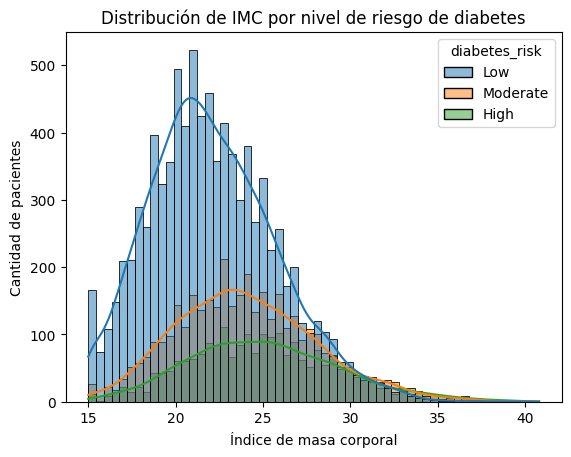

In [21]:
# histograma de bmi
sns.histplot(data=df, x='bmi', hue='diabetes_risk', kde=True)
plt.xlabel('Índice de masa corporal')
plt.ylabel('Cantidad de pacientes')
plt.title('Distribución de IMC por nivel de riesgo de diabetes')
plt.show()

Insights: el IMC muestra un ligero sesgo hacia la derecha, con la mayoría de los pacientes concentrados entre 18 y 27 aproximadamente. Los pacientes de riesgo alto se concentran más hacia valores altos de IMC que los de riesgo bajo, aunque las tres distribuciones se sobreponen bastante.

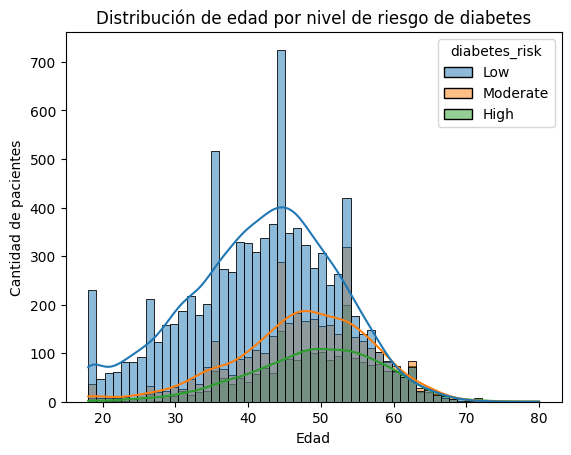

In [22]:
# histograma de age
sns.histplot(data=df, x='age', hue='diabetes_risk', kde=True)
plt.xlabel('Edad')
plt.ylabel('Cantidad de pacientes')
plt.title('Distribución de edad por nivel de riesgo de diabetes')
plt.show()

Insights: la distribución de edad es razonablemente simétrica, con el grueso de los pacientes entre 35 y 55 años. El grupo de riesgo alto se ve desplazado hacia edades mayores respecto al grupo de riesgo bajo, consistente con que la media de edad sube de 41.9 a 49.2 años entre riesgo bajo y alto.

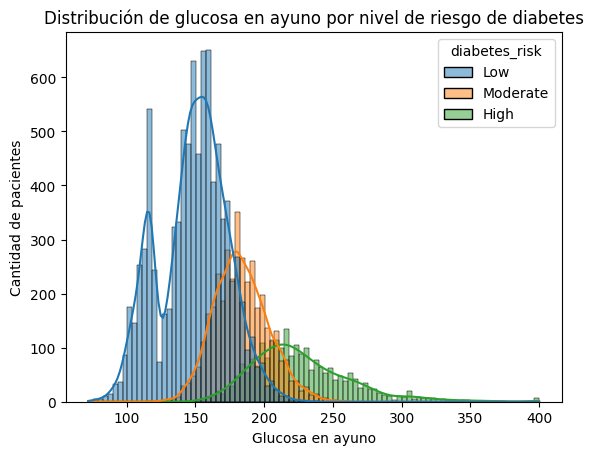

In [23]:
# histograma de fasting_blood_sugar
sns.histplot(data=df, x='fasting_blood_sugar', hue='diabetes_risk', kde=True)
plt.xlabel('Glucosa en ayuno')
plt.ylabel('Cantidad de pacientes')
plt.title('Distribución de glucosa en ayuno por nivel de riesgo de diabetes')
plt.show()

Insights: la glucosa en ayuno es la variable que más separa a los tres grupos de riesgo. El grupo de riesgo bajo se concentra en valores más bajos (media 148.3) mientras que el grupo de riesgo alto se desplaza claramente hacia valores más altos (media 226.5), con poca superposición entre los extremos de las distribuciones.

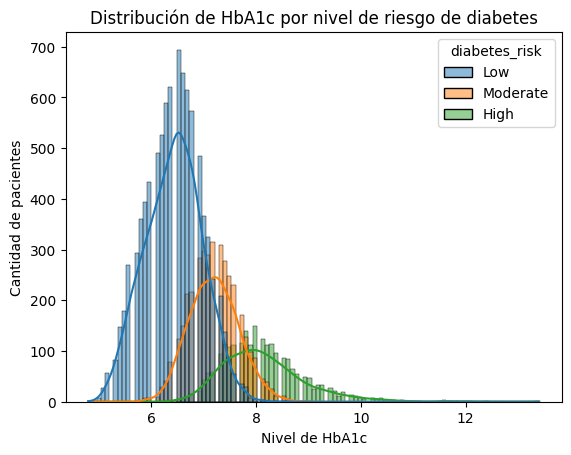

In [24]:
# histograma de hba1c_level
sns.histplot(data=df, x='hba1c_level', hue='diabetes_risk', kde=True)
plt.xlabel('Nivel de HbA1c')
plt.ylabel('Cantidad de pacientes')
plt.title('Distribución de HbA1c por nivel de riesgo de diabetes')
plt.show()

Insights: el HbA1c también separa bien a los grupos de riesgo. La media pasa de 6.43 en riesgo bajo a 7.20 en moderado y 8.14 en alto, con las tres distribuciones desplazándose hacia la derecha conforme aumenta el riesgo.

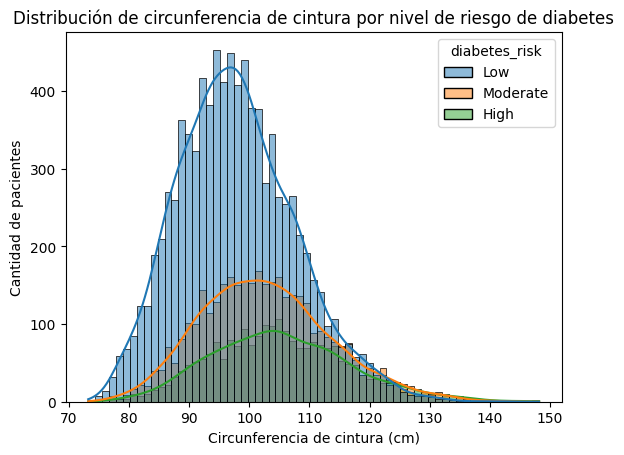

In [25]:
# histograma de waist_circumference_cm
sns.histplot(data=df, x='waist_circumference_cm', hue='diabetes_risk', kde=True)
plt.xlabel('Circunferencia de cintura (cm)')
plt.ylabel('Cantidad de pacientes')
plt.title('Distribución de circunferencia de cintura por nivel de riesgo de diabetes')
plt.show()

Insights: la circunferencia de cintura muestra un patrón similar al IMC, con el grupo de riesgo alto desplazado hacia valores más altos que el grupo de riesgo bajo, aunque con superposición considerable entre los tres grupos.

### 4.3 Boxplots por diabetes_risk y outliers

**Objetivo:**
Visualizar boxplots de las variables numéricas clave separadas por `diabetes_risk`, y calcular outliers con el método IQR para decidir si se conservan.

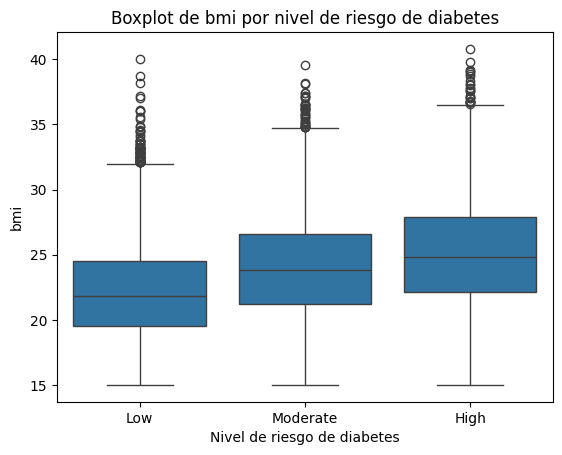

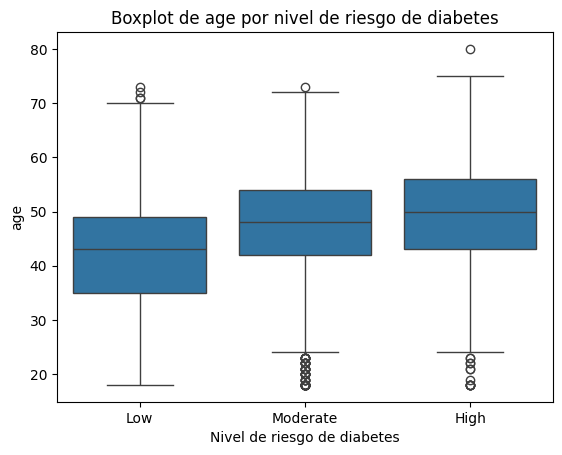

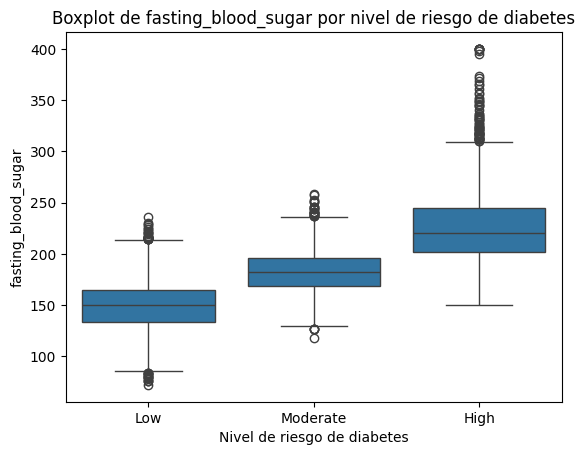

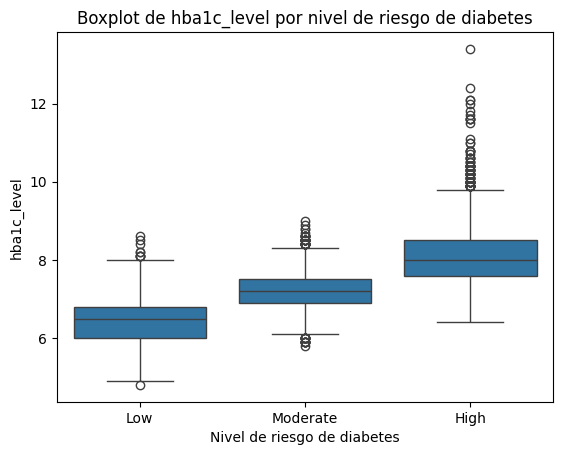

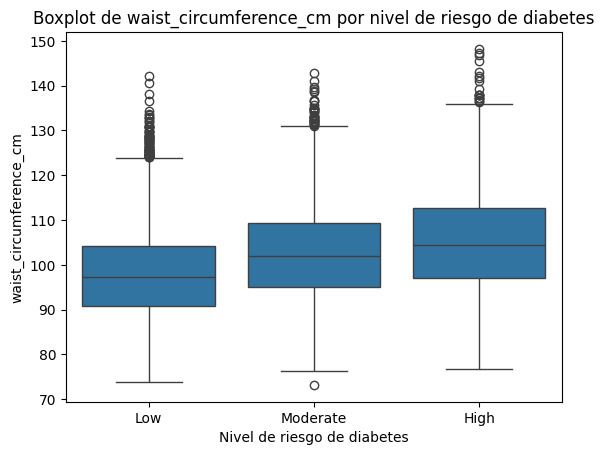

In [26]:
# boxplots por diabetes_risk
columnas_numericas = ['bmi', 'age', 'fasting_blood_sugar', 'hba1c_level', 'waist_circumference_cm']

for columna in columnas_numericas:
    sns.boxplot(data=df, x='diabetes_risk', y=columna)
    plt.title(f'Boxplot de {columna} por nivel de riesgo de diabetes')
    plt.xlabel('Nivel de riesgo de diabetes')
    plt.ylabel(columna)
    plt.show()

In [27]:
# calcular límites y cantidad de outliers con el método IQR
for columna in columnas_numericas:
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    print(f'{columna}: límite inferior = {limite_inferior:.2f}, límite superior = {limite_superior:.2f}, '
          f'cantidad de outliers = {len(outliers)}')

bmi: límite inferior = 11.85, límite superior = 33.85, cantidad de outliers = 153
age: límite inferior = 17.00, límite superior = 73.00, cantidad de outliers = 3
fasting_blood_sugar: límite inferior = 79.00, límite superior = 255.00, cantidad de outliers = 432
hba1c_level: límite inferior = 4.80, límite superior = 8.80, cantidad de outliers = 355
waist_circumference_cm: límite inferior = 70.90, límite superior = 128.50, cantidad de outliers = 167


**Insights:**
Los límites y cantidad de outliers por columna, calculados con el método IQR, son:

- `bmi`: límite inferior 11.85, límite superior 33.85, 153 outliers.
- `age`: límite inferior 17.00, límite superior 73.00, 3 outliers.
- `fasting_blood_sugar`: límite inferior 79.00, límite superior 255.00, 432 outliers.
- `hba1c_level`: límite inferior 4.80, límite superior 8.80, 355 outliers.
- `waist_circumference_cm`: límite inferior 70.90, límite superior 128.50, 167 outliers.

En este dataset los valores extremos corresponden a pacientes con cuadros clínicos reales (glucosa muy alta, HbA1c muy alto, IMC muy elevado), no a errores de captura, por lo que se conservan tal como están.

### 4.4 Variables categóricas vs riesgo de diabetes

**Objetivo:**
Revisar cómo se distribuye el riesgo de diabetes según `physical_activity_level`, `categoria_imc`, `family_history_diabetes` y `grupo_edad`, con tablas cruzadas normalizadas por fila y gráficas.

diabetes_risk                  Low   Moderate       High
physical_activity_level                                 
Sedentary                50.484848  28.505051  21.010101
Moderate                 59.090909  26.545455  14.363636
Active                   70.117647  20.098039   9.784314


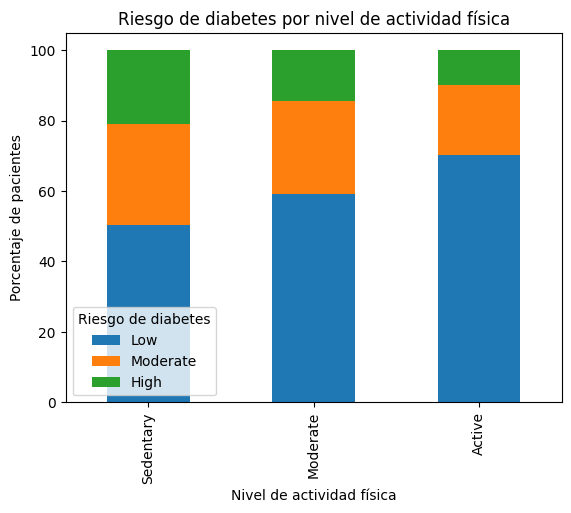

In [28]:
# crosstab de physical_activity_level vs diabetes_risk, normalizado por fila
tabla_actividad = pd.crosstab(df['physical_activity_level'], df['diabetes_risk'], normalize='index') * 100
print(tabla_actividad)

tabla_actividad.plot(kind='bar', stacked=True)
plt.xlabel('Nivel de actividad física')
plt.ylabel('Porcentaje de pacientes')
plt.title('Riesgo de diabetes por nivel de actividad física')
plt.legend(title='Riesgo de diabetes')
plt.show()

diabetes_risk        Low   Moderate       High
categoria_imc                                 
Bajo peso      79.075014  15.002820   5.922166
Normal         67.832625  21.428571  10.738804
Sobrepeso      58.285714  27.085714  14.628571
Obesidad       42.774309  32.604817  24.620874


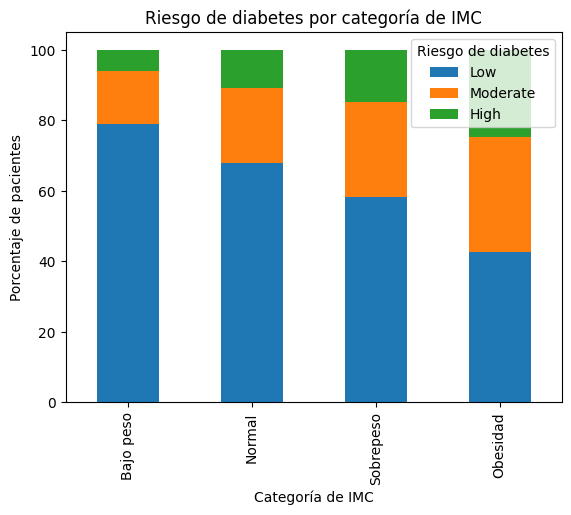

In [29]:
# crosstab de categoria_imc vs diabetes_risk, normalizado por fila
tabla_imc = pd.crosstab(df['categoria_imc'], df['diabetes_risk'], normalize='index') * 100
print(tabla_imc)

tabla_imc.plot(kind='bar', stacked=True)
plt.xlabel('Categoría de IMC')
plt.ylabel('Porcentaje de pacientes')
plt.title('Riesgo de diabetes por categoría de IMC')
plt.legend(title='Riesgo de diabetes')
plt.show()

diabetes_risk                  Low   Moderate       High
family_history_diabetes                                 
No                       65.856909  21.678967  12.464125
Yes                      49.103738  31.178490  19.717773


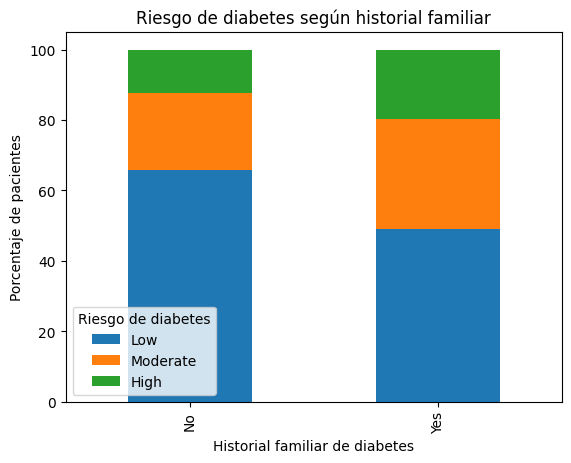

In [30]:
# crosstab de family_history_diabetes vs diabetes_risk, normalizado por fila
tabla_familia = pd.crosstab(df['family_history_diabetes'], df['diabetes_risk'], normalize='index') * 100
print(tabla_familia)

tabla_familia.plot(kind='bar', stacked=True)
plt.xlabel('Historial familiar de diabetes')
plt.ylabel('Porcentaje de pacientes')
plt.title('Riesgo de diabetes según historial familiar')
plt.legend(title='Riesgo de diabetes')
plt.show()

diabetes_risk        Low   Moderate       High
grupo_edad                                    
Menor de 30    83.870968  12.023460   4.105572
30 a 44        70.024399  19.571279  10.404322
45 a 59        50.639750  30.636906  18.723344
60 o más       31.944444  35.648148  32.407407


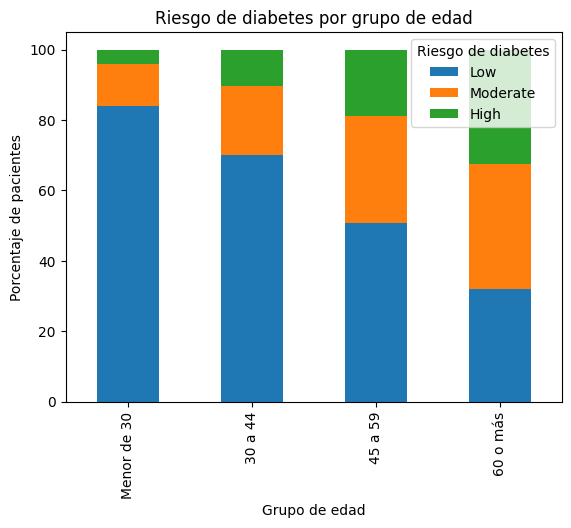

In [31]:
# crosstab de grupo_edad vs diabetes_risk, normalizado por fila
tabla_edad = pd.crosstab(df['grupo_edad'], df['diabetes_risk'], normalize='index') * 100
print(tabla_edad)

tabla_edad.plot(kind='bar', stacked=True)
plt.xlabel('Grupo de edad')
plt.ylabel('Porcentaje de pacientes')
plt.title('Riesgo de diabetes por grupo de edad')
plt.legend(title='Riesgo de diabetes')
plt.show()

**Insights:**
- Actividad física: el porcentaje de riesgo alto baja de 21.0% en Sedentary a 14.4% en Moderate y 9.8% en Active. El porcentaje de riesgo bajo sube de 50.5% en Sedentary a 70.1% en Active. Esto confirma una asociación clara entre mayor actividad física y menor riesgo de diabetes.
- Categoría de IMC: el riesgo alto pasa de 5.9% en Bajo peso a 10.7% en Normal, 14.6% en Sobrepeso y 24.6% en Obesidad. El patrón es consistente y creciente con la categoría de IMC.
- Historial familiar: los pacientes con historial familiar de diabetes (`Yes`) tienen 19.7% de riesgo alto, contra 12.5% en quienes no tienen historial familiar (`No`).
- Grupo de edad: el riesgo alto sube de 4.1% en menores de 30 años a 10.4% en el grupo de 30 a 44, 18.7% en el grupo de 45 a 59 y 32.4% en el de 60 o más. La edad muestra el gradiente más marcado de los cuatro factores revisados.

### 4.5 Matriz de correlación de Spearman

**Objetivo:**
Calcular la correlación de Spearman entre las variables numéricas, incluyendo versiones codificadas de `diabetes_risk` (0, 1, 2) y `physical_activity_level` (0, 1, 2), y visualizarla con un heatmap.

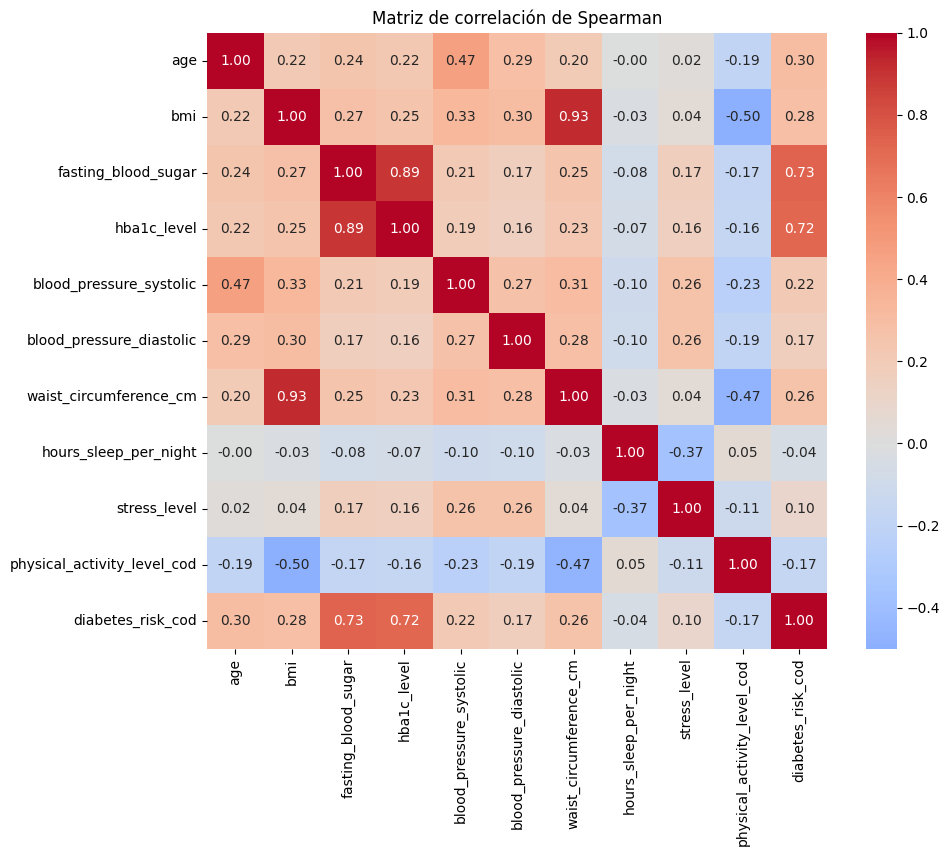

In [32]:
# codificar riesgo y actividad física como numéricas ordinales
df['diabetes_risk_cod'] = df['diabetes_risk'].cat.codes
df['physical_activity_level_cod'] = df['physical_activity_level'].cat.codes

columnas_corr = ['age', 'bmi', 'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic',
                  'blood_pressure_diastolic', 'waist_circumference_cm', 'hours_sleep_per_night',
                  'stress_level', 'physical_activity_level_cod', 'diabetes_risk_cod']

correlacion = df[columnas_corr].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación de Spearman')
plt.show()

**Insights:**
Las correlaciones de Spearman de cada variable con `diabetes_risk_cod` son: `fasting_blood_sugar` 0.73, `hba1c_level` 0.72, `age` 0.30, `bmi` 0.28, `waist_circumference_cm` 0.26, `blood_pressure_systolic` 0.22, `blood_pressure_diastolic` 0.17, `stress_level` 0.10, `hours_sleep_per_night` -0.04 y `physical_activity_level_cod` -0.17.

Como se esperaba, la glucosa en ayuno y el HbA1c son las variables con mayor correlación con el riesgo de diabetes, seguidas de la edad, el IMC y la circunferencia de cintura. El nivel de actividad física muestra una correlación negativa (-0.17), es decir, a mayor actividad física, menor riesgo, aunque la relación es más débil que la de los marcadores clínicos directos.

### Observaciones del Paso 4

En este paso revisamos el comportamiento general de las variables numéricas y categóricas del dataset, tanto de forma global como separadas por nivel de riesgo de diabetes. Las variables clínicas diferencian claramente a los grupos de riesgo: la glucosa en ayuno promedio pasa de 148.3 (riesgo bajo) a 226.5 (riesgo alto), el HbA1c promedio pasa de 6.43 a 8.14, el IMC promedio de 22.1 a 25.1, y la edad promedio de 41.9 a 49.2 años.

El nivel de actividad física, el historial familiar y la edad también muestran patrones consistentes: el riesgo alto baja de 21.0% en pacientes sedentarios a 9.8% en pacientes activos; sube de 5.9% en Bajo peso a 24.6% en Obesidad; es de 19.7% en pacientes con historial familiar de diabetes contra 12.5% sin historial; y sube de 4.1% en menores de 30 años a 32.4% en el grupo de 60 años o más.

La matriz de correlación de Spearman confirma este panorama: `fasting_blood_sugar` (0.73) y `hba1c_level` (0.72) son las variables con mayor correlación con el riesgo, seguidas de `age` (0.30), `bmi` (0.28) y `waist_circumference_cm` (0.26), mientras que `physical_activity_level_cod` muestra correlación negativa (-0.17). Estos hallazgos descriptivos nos dan la base para las pruebas de hipótesis formales que se abordan en los siguientes pasos del análisis.

## Paso 5: Pruebas de hipótesis

### 5.1 Planteamiento

**Objetivo:** Poner a prueba, de forma estadística, la pregunta central del análisis: si existe una asociación significativa entre el nivel de actividad física y el IMC como predictores del riesgo de diabetes. Se trabaja con un nivel de significancia alfa = 0.05 en todas las pruebas.

Preguntas que se van a responder en este paso:

- H1: ¿El nivel de actividad física está asociado con el nivel de riesgo de diabetes?
- H2: ¿El IMC promedio difiere entre los niveles de riesgo de diabetes?
- H3: ¿El IMC promedio difiere entre los niveles de actividad física?
- H4: ¿La asociación entre IMC y riesgo de diabetes se mantiene dentro de cada nivel de actividad física, o cambia de fuerza?
- ¿La actividad física sigue asociada con el riesgo de diabetes una vez que se controla por categoría de IMC?
- Factores secundarios: antecedentes familiares, género, tipo de dieta y estatus de fumador, ¿también están asociados con el riesgo de diabetes?
- Validación: ¿la glucosa en ayunas y la hemoglobina glucosilada (HbA1c) confirman que la etiqueta de riesgo tiene sentido clínico?

**Criterio de pruebas:** para comparar variables categóricas se usa chi cuadrado de independencia. Para comparar el IMC promedio entre los tres niveles de una variable se usa el ANOVA de Welch como prueba global, y después una sola prueba t de Welch planeada entre los dos grupos extremos (por ejemplo, riesgo High contra riesgo Low). La prueba t compara las medias de dos grupos; se usa la versión de Welch porque no asume varianzas iguales. El tamaño del efecto se mide con eta cuadrada (ANOVA) y con la d de Cohen (prueba t).

Cada prueba se evalúa contra alfa = 0.05. Como se corren varias pruebas en este paso, los resultados con p cercano a 0.05 se interpretan con cautela, poniendo más atención en el tamaño del efecto que solo en el p valor.

Importante: todas las pruebas de este paso muestran asociación, no causalidad. Un resultado significativo no implica que una variable cause la otra.


In [33]:
# librerías adicionales para pruebas de hipótesis
from scipy import stats

# se recarga el dataframe limpio, ya que al guardar a csv se pierden los tipos category
df = pd.read_csv('../data/clean/diabetes_risk_clean.csv')
df['diabetes_risk'] = pd.Categorical(df['diabetes_risk'], categories=['Low', 'Moderate', 'High'], ordered=True)
df['physical_activity_level'] = pd.Categorical(df['physical_activity_level'], categories=['Sedentary', 'Moderate', 'Active'], ordered=True)
df['categoria_imc'] = pd.Categorical(df['categoria_imc'], categories=['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad'], ordered=True)

alfa = 0.05
niveles_riesgo = ['Low', 'Moderate', 'High']
df.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,...,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk,categoria_imc,grupo_edad
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,...,8,178,7.3,146,90,107.1,High,Low,Obesidad,45 a 59
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,...,6,152,6.9,156,100,93.8,Low,Low,Normal,45 a 59
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,...,7,168,6.6,150,102,113.5,Low,High,Obesidad,45 a 59
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,...,5,155,6.7,126,92,109.6,Middle,Low,Normal,30 a 44
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,...,10,188,6.7,130,90,80.8,High,Low,Bajo peso,45 a 59


In [34]:
# función auxiliar: chi cuadrado de independencia junto con la V de Cramér
def prueba_chi2_cramer(tabla):
    chi2, p, gl, esperado = stats.chi2_contingency(tabla)
    n = tabla.values.sum()
    filas, columnas = tabla.shape
    v = np.sqrt((chi2 / n) / (min(filas - 1, columnas - 1)))
    return chi2, p, gl, esperado, v

### 5.2 H1: Actividad física y riesgo de diabetes

**Objetivo:** Evaluar si el nivel de actividad física y el nivel de riesgo de diabetes son independientes, con una prueba chi cuadrado de independencia.

- H0: el nivel de actividad física y el riesgo de diabetes son independientes.
- H1: el nivel de actividad física y el riesgo de diabetes están asociados.


In [35]:
# tabla de contingencia entre actividad física y riesgo
tabla_h1 = pd.crosstab(df['physical_activity_level'], df['diabetes_risk'])
tabla_h1

diabetes_risk,Low,Moderate,High
physical_activity_level,,,
Sedentary,2499,1411,1040
Moderate,2925,1314,711
Active,3576,1025,499


In [36]:
# chi cuadrado de independencia y V de Cramér
chi2_h1, p_h1, gl_h1, esperado_h1, v_h1 = prueba_chi2_cramer(tabla_h1)

print(f'chi2 = {chi2_h1:.2f}, gl = {gl_h1}, p = {p_h1:.3e}')
print('frecuencia esperada mínima:', round(esperado_h1.min(), 2))
print('V de Cramér:', round(v_h1, 4))

chi2 = 453.49, gl = 4, p = 7.646e-97
frecuencia esperada mínima: 742.5
V de Cramér: 0.1229


Insights:

La frecuencia esperada mínima es de 742.5, muy por encima del umbral de 5, así que se cumple el supuesto para usar chi cuadrado.

chi2 = 453.49, con gl = 4 y p = 7.65e-97, un valor mucho menor que alfa = 0.05. Rechazamos H0: existe una asociación significativa entre el nivel de actividad física y el riesgo de diabetes.

La V de Cramér es 0.1229, un tamaño de efecto pequeño según los umbrales convencionales (cercano a 0.1). La asociación es estadísticamente significativa pero de magnitud modesta, algo esperable con un tamaño de muestra de 15,000 pacientes, donde incluso diferencias pequeñas resultan significativas.

In [37]:
# residuos estandarizados ajustados, para ver qué celdas explican la asociación
n_h1 = tabla_h1.values.sum()
suma_filas = tabla_h1.sum(axis=1).values.reshape(-1, 1)
suma_columnas = tabla_h1.sum(axis=0).values.reshape(1, -1)
residuos_h1 = (tabla_h1.values - esperado_h1) / np.sqrt(
    esperado_h1 * (1 - suma_filas / n_h1) * (1 - suma_columnas / n_h1)
)
residuos_h1 = pd.DataFrame(residuos_h1, index=tabla_h1.index, columns=tabla_h1.columns)
residuos_h1.round(2)

diabetes_risk,Low,Moderate,High
physical_activity_level,,,
Sedentary,-16.69,6.96,14.47
Moderate,-1.60,3.07,-1.53
Active,18.15,-9.95,-12.84


Insights:

Usando el criterio habitual de considerar significativa una celda cuando el residuo ajustado supera 1.96 en valor absoluto, se observa:

- Sedentarios: muchos menos casos de riesgo Low de los esperados (residuo -16.69) y muchos más casos de riesgo High de los esperados (residuo 14.47). También más riesgo Moderate del esperado (6.96).
- Activos: muchos más casos de riesgo Low de los esperados (residuo 18.15) y menos casos de riesgo Moderate (-9.95) y High (-12.84) de los esperados.
- Actividad moderada: los residuos en Low (-1.60) y High (-1.53) no superan 1.96, es decir, ese grupo no se aleja mucho de lo esperado bajo independencia en esos dos niveles; solo el riesgo Moderate (3.07) supera el umbral.

Esto nos confirma que la asociación entre actividad física y riesgo de diabetes la explican sobre todo los extremos: el sedentarismo empuja hacia más riesgo alto y la actividad activa empuja hacia más riesgo bajo.

### 5.3 H2: IMC entre niveles de riesgo de diabetes

**Objetivo:** Evaluar si el IMC promedio difiere entre los tres niveles de riesgo de diabetes.

- H0: la distribución del IMC es la misma en los tres niveles de riesgo.
- H1: al menos un nivel de riesgo difiere de los demás en su IMC.


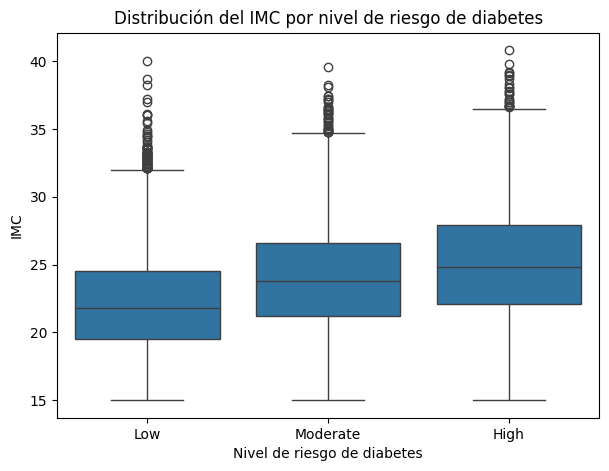

In [38]:
# boxplot de apoyo, IMC por nivel de riesgo
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='diabetes_risk', y='bmi', order=niveles_riesgo)
plt.xlabel('Nivel de riesgo de diabetes')
plt.ylabel('IMC')
plt.title('Distribución del IMC por nivel de riesgo de diabetes')
plt.show()

Low: n = 9000, estadístico = 336.00, p = 1.092e-73
Moderate: n = 3750, estadístico = 97.16, p = 7.970e-22
High: n = 2250, estadístico = 52.73, p = 3.539e-12


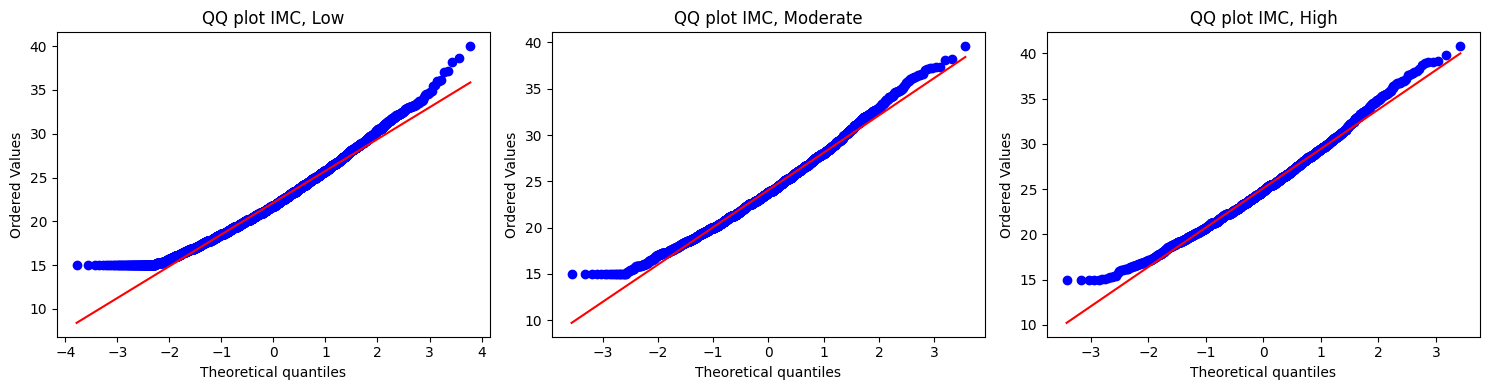

In [39]:
# verificación de normalidad con D'Agostino Pearson, con n grande Shapiro no es adecuado
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, nivel in zip(axes, niveles_riesgo):
    muestra = df.loc[df['diabetes_risk'] == nivel, 'bmi']
    estad, p_norm = stats.normaltest(muestra)
    print(f'{nivel}: n = {len(muestra)}, estadístico = {estad:.2f}, p = {p_norm:.3e}')
    stats.probplot(muestra, dist='norm', plot=ax)
    ax.set_title(f'QQ plot IMC, {nivel}')
plt.tight_layout()
plt.show()

Insights:

Low: n = 9000, estadístico = 336.00, p = 1.09e-73. Moderate: n = 3750, estadístico = 97.16, p = 7.97e-22. High: n = 2250, estadístico = 52.73, p = 3.54e-12. En los tres grupos p es menor que alfa, así que se rechaza la normalidad según la prueba de D'Agostino Pearson, y los QQ plot muestran que el IMC se aleja de la recta teórica, sobre todo en la cola derecha (el IMC tiene un límite inferior natural cerca de 0 y algunos valores altos, lo que produce sesgo hacia la derecha).

Sin embargo, los tamaños de muestra son grandes (9000, 3750 y 2250 observaciones). Por el teorema del límite central, la distribución muestral de la media se aproxima a una normal aunque los datos originales no lo sean, así que un ANOVA (o su versión de Welch) y la prueba t de Welch siguen siendo razonables.

In [40]:
# homogeneidad de varianzas con Levene
grupos_riesgo_bmi = [df.loc[df['diabetes_risk'] == nivel, 'bmi'] for nivel in niveles_riesgo]
lev_stat_h2, lev_p_h2 = stats.levene(*grupos_riesgo_bmi)
print(f'Levene: estadístico = {lev_stat_h2:.2f}, p = {lev_p_h2:.3e}')

Levene: estadístico = 62.08, p = 1.418e-27


Insights:

Levene: estadístico = 62.08, p = 1.42e-27, menor que alfa. No se cumple la homogeneidad de varianzas entre los grupos, así que en lugar del ANOVA clásico se usa el ANOVA de Welch, que no asume varianzas iguales.

In [41]:
# función auxiliar para ANOVA de Welch, para cuando las varianzas no son homogéneas
def anova_welch(grupos):
    k = len(grupos)
    ni = np.array([len(g) for g in grupos])
    mi = np.array([g.mean() for g in grupos])
    vi = np.array([g.var(ddof=1) for g in grupos])
    wi = ni / vi
    media_ponderada = np.sum(wi * mi) / np.sum(wi)
    numerador = np.sum(wi * (mi - media_ponderada) ** 2) / (k - 1)
    termino = np.sum((1 - wi / np.sum(wi)) ** 2 / (ni - 1))
    denominador = 1 + (2 * (k - 2) / (k ** 2 - 1)) * termino
    F = numerador / denominador
    gl1 = k - 1
    gl2 = (k ** 2 - 1) / (3 * termino)
    p = stats.f.sf(F, gl1, gl2)  # cola derecha, evita que p se redondee a 0
    return F, gl1, gl2, p

In [42]:
# función auxiliar: prueba t de Welch con intervalo de confianza y d de Cohen
def prueba_t_welch(grupo_a, grupo_b):
    resultado = stats.ttest_ind(grupo_a, grupo_b, equal_var=False)
    ic = resultado.confidence_interval(confidence_level=0.95)
    diferencia = grupo_a.mean() - grupo_b.mean()
    d = diferencia / np.sqrt((grupo_a.var(ddof=1) + grupo_b.var(ddof=1)) / 2)
    return resultado.statistic, resultado.df, resultado.pvalue, diferencia, ic.low, ic.high, d

In [43]:
# ANOVA de Welch, IMC entre niveles de riesgo
F_h2, gl1_h2, gl2_h2, p_h2 = anova_welch(grupos_riesgo_bmi)
print(f'ANOVA de Welch: F = {F_h2:.2f}, gl1 = {gl1_h2}, gl2 = {gl2_h2:.1f}, p = {p_h2:.3e}')

# tamaño del efecto con eta cuadrada
media_general_h2 = df['bmi'].mean()
ss_entre_h2 = sum(len(g) * (g.mean() - media_general_h2) ** 2 for g in grupos_riesgo_bmi)
ss_total_h2 = ((df['bmi'] - media_general_h2) ** 2).sum()
eta2_h2 = ss_entre_h2 / ss_total_h2
print(f'eta cuadrada = {eta2_h2:.4f}')

df.groupby('diabetes_risk', observed=True)['bmi'].agg(['mean', 'std'])

ANOVA de Welch: F = 640.66, gl1 = 2, gl2 = 5116.5, p = 4.986e-249
eta cuadrada = 0.0853


,mean,std
diabetes_risk,,
Low,22.133200,3.654739
Moderate,24.064240,4.052539
High,25.108533,4.365349


Insights:

ANOVA de Welch: F = 640.66, gl1 = 2, gl2 = 5116.5, p = 4.99e-249, mucho menor que alfa. Rechazamos H0: el IMC promedio sí difiere entre los niveles de riesgo de diabetes.

La eta cuadrada es 0.0853, un tamaño de efecto mediano según los umbrales convencionales (entre 0.06 y 0.14): el nivel de riesgo explica cerca del 8.5% de la variación del IMC. Las medias confirman la tendencia: IMC promedio de 22.13 en riesgo Low, 24.06 en Moderate y 25.11 en High. El IMC sube conforme sube el riesgo.

**Prueba t de Welch: riesgo High contra riesgo Low**

**Objetivo:** El ANOVA solo dice que al menos un grupo es distinto. Para medir qué tan grande es la diferencia entre los extremos, se hace una sola comparación planeada entre los pacientes de riesgo High y los de riesgo Low.

- H0: el IMC promedio es igual en riesgo High y en riesgo Low.
- H1: el IMC promedio es distinto entre riesgo High y riesgo Low.

In [44]:
# prueba t de Welch, IMC de riesgo High contra riesgo Low
imc_high = df.loc[df['diabetes_risk'] == 'High', 'bmi']
imc_low = df.loc[df['diabetes_risk'] == 'Low', 'bmi']
t_h2, gl_t_h2, p_t_h2, dif_h2, ic_low_h2, ic_high_h2, d_h2 = prueba_t_welch(imc_high, imc_low)

print(f't = {t_h2:.2f}, gl = {gl_t_h2:.1f}, p = {p_t_h2:.3e}')
print(f'diferencia de medias = {dif_h2:.2f}, IC 95% = ({ic_low_h2:.2f}, {ic_high_h2:.2f})')
print(f'd de Cohen = {d_h2:.3f}')

t = 29.82, gl = 3082.6, p = 6.292e-172
diferencia de medias = 2.98, IC 95% = (2.78, 3.17)
d de Cohen = 0.739


Insights:

t = 29.82, gl = 3082.6, p = 6.29e-172. Rechazamos H0: los pacientes de riesgo alto tienen un IMC promedio distinto al de los de riesgo bajo.

La diferencia de medias es de 2.98 puntos de IMC (25.11 contra 22.13), con un intervalo de confianza del 95% entre 2.78 y 3.17. Es decir, con un 95% de confianza, los pacientes de riesgo alto tienen entre 2.8 y 3.2 puntos más de IMC que los de riesgo bajo. La d de Cohen es 0.739, un tamaño de efecto mediano, cercano a grande (umbrales convencionales: 0.2 pequeño, 0.5 mediano, 0.8 grande).

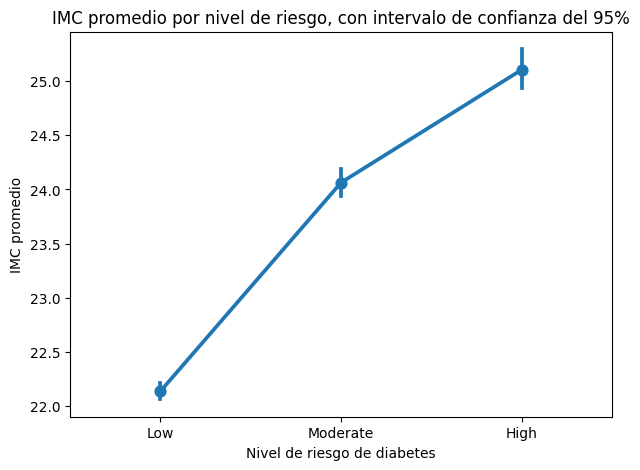

In [45]:
# gráfica de apoyo, IMC promedio con intervalo de confianza del 95%
plt.figure(figsize=(7, 5))
sns.pointplot(data=df, x='diabetes_risk', y='bmi', order=niveles_riesgo, errorbar=('ci', 95))
plt.xlabel('Nivel de riesgo de diabetes')
plt.ylabel('IMC promedio')
plt.title('IMC promedio por nivel de riesgo, con intervalo de confianza del 95%')
plt.show()

### 5.4 H3: IMC entre niveles de actividad física

**Objetivo:** Evaluar si el IMC promedio difiere entre los tres niveles de actividad física, con el mismo procedimiento que en 5.3.

- H0: la distribución del IMC es la misma en los tres niveles de actividad física.
- H1: al menos un nivel de actividad física difiere de los demás en su IMC.


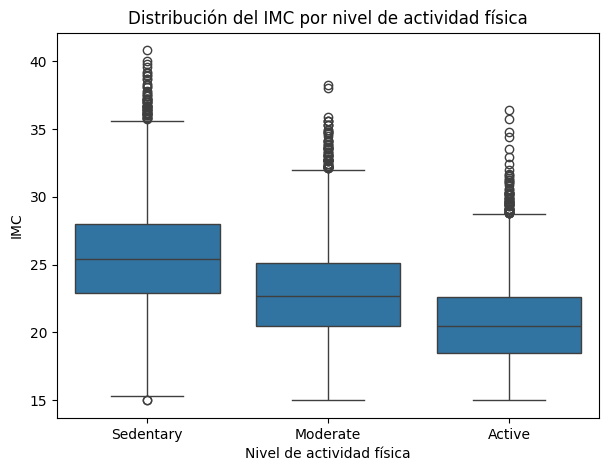

In [46]:
# boxplot de apoyo, IMC por nivel de actividad física
niveles_actividad = ['Sedentary', 'Moderate', 'Active']
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='physical_activity_level', y='bmi', order=niveles_actividad)
plt.xlabel('Nivel de actividad física')
plt.ylabel('IMC')
plt.title('Distribución del IMC por nivel de actividad física')
plt.show()

Sedentary: n = 4950, estadístico = 131.48, p = 2.820e-29
Moderate: n = 4950, estadístico = 192.62, p = 1.492e-42
Active: n = 5100, estadístico = 264.99, p = 2.868e-58


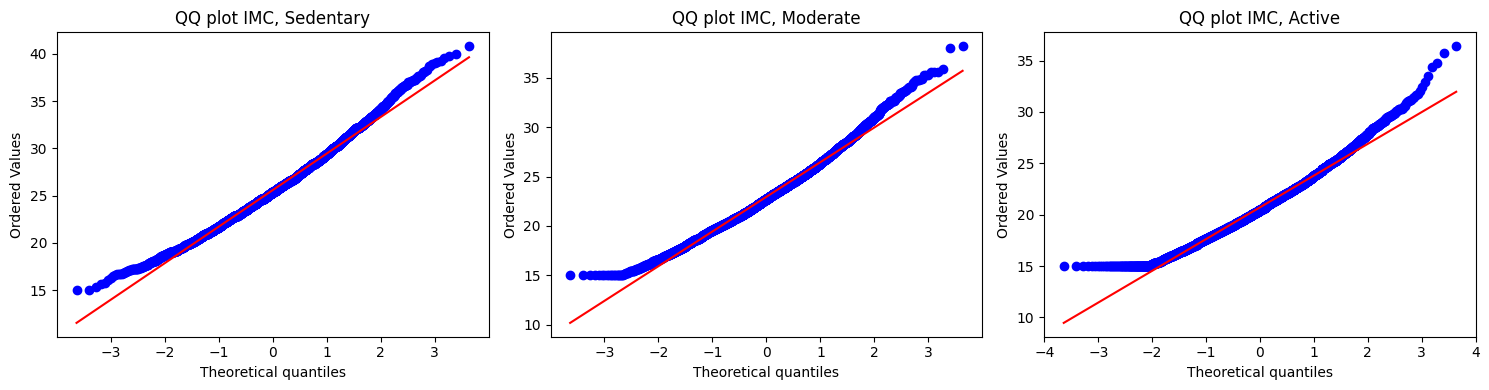

In [47]:
# verificación de normalidad con D'Agostino Pearson
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, nivel in zip(axes, niveles_actividad):
    muestra = df.loc[df['physical_activity_level'] == nivel, 'bmi']
    estad, p_norm = stats.normaltest(muestra)
    print(f'{nivel}: n = {len(muestra)}, estadístico = {estad:.2f}, p = {p_norm:.3e}')
    stats.probplot(muestra, dist='norm', plot=ax)
    ax.set_title(f'QQ plot IMC, {nivel}')
plt.tight_layout()
plt.show()

Insights:

Sedentary: n = 4950, estadístico = 131.48, p = 2.82e-29. Moderate: n = 4950, estadístico = 192.62, p = 1.49e-42. Active: n = 5100, estadístico = 264.99, p = 2.87e-58. Igual que en 5.3, se rechaza la normalidad en los tres grupos, pero los tamaños de muestra son grandes, así que por el teorema del límite central se puede confiar en el ANOVA de Welch y en la prueba t de Welch.

In [48]:
# homogeneidad de varianzas con Levene
grupos_actividad_bmi = [df.loc[df['physical_activity_level'] == nivel, 'bmi'] for nivel in niveles_actividad]
lev_stat_h3, lev_p_h3 = stats.levene(*grupos_actividad_bmi)
print(f'Levene: estadístico = {lev_stat_h3:.2f}, p = {lev_p_h3:.3e}')

Levene: estadístico = 97.20, p = 1.147e-42


Insights:

Levene: estadístico = 97.20, p = 1.15e-42, menor que alfa. Tampoco se cumple la homogeneidad de varianzas, así que de nuevo se usa el ANOVA de Welch en lugar del ANOVA clásico.

In [49]:
# ANOVA de Welch, IMC entre niveles de actividad física
F_h3, gl1_h3, gl2_h3, p_h3 = anova_welch(grupos_actividad_bmi)
print(f'ANOVA de Welch: F = {F_h3:.2f}, gl1 = {gl1_h3}, gl2 = {gl2_h3:.1f}, p = {p_h3:.3e}')

# tamaño del efecto con eta cuadrada
media_general_h3 = df['bmi'].mean()
ss_entre_h3 = sum(len(g) * (g.mean() - media_general_h3) ** 2 for g in grupos_actividad_bmi)
ss_total_h3 = ((df['bmi'] - media_general_h3) ** 2).sum()
eta2_h3 = ss_entre_h3 / ss_total_h3
print(f'eta cuadrada = {eta2_h3:.4f}')

df.groupby('physical_activity_level', observed=True)['bmi'].agg(['mean', 'std'])

ANOVA de Welch: F = 2416.33, gl1 = 2, gl2 = 9877.7, p = 0.000e+00
eta cuadrada = 0.2432


,mean,std
physical_activity_level,,
Sedentary,25.591333,3.879289
Moderate,22.947636,3.533703
Active,20.718824,3.118046


Insights:

ANOVA de Welch: F = 2416.33, gl1 = 2, gl2 = 9877.7, p prácticamente 0 (el valor es tan pequeño que la computadora lo redondea a 0). Rechazamos H0: el IMC promedio sí difiere entre los niveles de actividad física.

La eta cuadrada es 0.2432, un tamaño de efecto grande según los umbrales convencionales (mayor a 0.14), el más fuerte de todo este paso: el nivel de actividad física explica cerca del 24% de la variación del IMC. Las medias lo confirman: IMC promedio de 25.59 en sedentarios, 22.95 en actividad moderada y 20.72 en activos. A mayor actividad física, menor IMC promedio.

**Prueba t de Welch: sedentarios contra activos**

**Objetivo:** Medir la diferencia de IMC entre los dos extremos de actividad física con una sola comparación planeada.

- H0: el IMC promedio es igual en pacientes sedentarios y activos.
- H1: el IMC promedio es distinto entre pacientes sedentarios y activos.

In [50]:
# prueba t de Welch, IMC de sedentarios contra activos
imc_sedentario = df.loc[df['physical_activity_level'] == 'Sedentary', 'bmi']
imc_activo = df.loc[df['physical_activity_level'] == 'Active', 'bmi']
t_h3, gl_t_h3, p_t_h3, dif_h3, ic_low_h3, ic_high_h3, d_h3 = prueba_t_welch(imc_sedentario, imc_activo)

print(f't = {t_h3:.2f}, gl = {gl_t_h3:.1f}, p = {p_t_h3:.3e}')
print(f'diferencia de medias = {dif_h3:.2f}, IC 95% = ({ic_low_h3:.2f}, {ic_high_h3:.2f})')
print(f'd de Cohen = {d_h3:.3f}')

t = 69.28, gl = 9482.6, p = 0.000e+00
diferencia de medias = 4.87, IC 95% = (4.73, 5.01)
d de Cohen = 1.385


Insights:

t = 69.28, gl = 9482.6, p prácticamente 0 (el valor es tan pequeño que se redondea a 0). Rechazamos H0: sedentarios y activos tienen un IMC promedio distinto.

La diferencia de medias es de 4.87 puntos de IMC (25.59 contra 20.72), con un intervalo de confianza del 95% entre 4.73 y 5.01. La d de Cohen es 1.385, un tamaño de efecto grande, muy por encima del umbral de 0.8. Es la diferencia de IMC más marcada de todo el análisis.

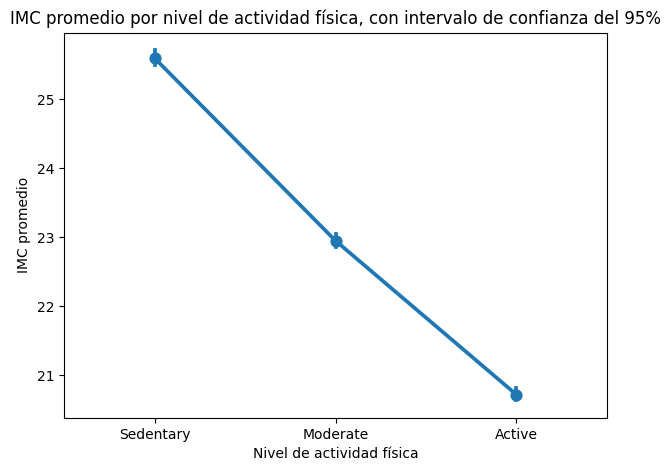

In [51]:
# gráfica de apoyo, IMC promedio con intervalo de confianza del 95%
plt.figure(figsize=(7, 5))
sns.pointplot(data=df, x='physical_activity_level', y='bmi', order=niveles_actividad, errorbar=('ci', 95))
plt.xlabel('Nivel de actividad física')
plt.ylabel('IMC promedio')
plt.title('IMC promedio por nivel de actividad física, con intervalo de confianza del 95%')
plt.show()

### 5.5 H4: IMC y riesgo de diabetes dentro de cada nivel de actividad física

**Objetivo:** Revisar si la asociación entre categoría de IMC y riesgo de diabetes se mantiene dentro de cada nivel de actividad física, y si su fuerza cambia entre estratos. Se corre una prueba chi cuadrado de `categoria_imc` contra `diabetes_risk` por separado en cada estrato de `physical_activity_level`. Aclaración: comparar la V de Cramér entre estratos es un indicio descriptivo de que la fuerza de la asociación cambia, no una prueba formal de interacción (para eso haría falta un modelo con término de interacción explícito), así que cualquier atenuación que se observe se reporta como posible, no como confirmada.

- H0 (por estrato): la categoría de IMC y el riesgo de diabetes son independientes dentro de ese nivel de actividad física.
- H1 (por estrato): la categoría de IMC y el riesgo de diabetes están asociados dentro de ese nivel de actividad física.


In [52]:
# chi cuadrado de categoria_imc vs diabetes_risk, una prueba por estrato de actividad física
resultados_h4 = []
for nivel_act in niveles_actividad:
    sub = df[df['physical_activity_level'] == nivel_act]
    tabla_estrato = pd.crosstab(sub['categoria_imc'], sub['diabetes_risk'])
    chi2_e, p_e, gl_e, esperado_e, v_e = prueba_chi2_cramer(tabla_estrato)
    resultados_h4.append({
        'actividad_fisica': nivel_act,
        'chi2': chi2_e,
        'gl': gl_e,
        'p': p_e,
        'esperado_min': esperado_e.min(),
        'V_cramer': v_e,
    })

resumen_h4 = pd.DataFrame(resultados_h4)
resumen_h4

,actividad_fisica,chi2,gl,p,esperado_min,V_cramer
0,Sedentary,272.848595,6,5.330900e-56,19.119192,0.166013
1,Moderate,243.751329,6,8.871599e-50,60.758182,0.156912
2,Active,151.999494,6,2.922476e-30,47.258235,0.122073


Insights:

Sedentarios: chi2 = 272.85, gl = 6, p = 5.33e-56, V de Cramér = 0.1660, esperado mínimo = 19.12. Actividad moderada: chi2 = 243.75, gl = 6, p = 8.87e-50, V de Cramér = 0.1569, esperado mínimo = 60.76. Activos: chi2 = 152.00, gl = 6, p = 2.92e-30, V de Cramér = 0.1221, esperado mínimo = 47.26. En los tres estratos la frecuencia esperada mínima supera 5, así que se cumple el supuesto del chi cuadrado.

En los tres niveles de actividad física se rechaza H0 (p mucho menor que alfa): la asociación entre categoría de IMC y riesgo de diabetes se mantiene dentro de cada estrato. La fuerza de la asociación, medida con la V de Cramér, no es igual entre estratos: es más alta en sedentarios (V = 0.166) y más baja en activos (V = 0.122), con actividad moderada en medio (V = 0.157). Esta comparación de la V entre estratos es descriptiva, no una prueba formal de interacción, así que se interpreta con cautela: es un indicio de que la actividad física podría atenuar un poco la asociación entre IMC y riesgo conforme aumenta el nivel de actividad, sin que esto confirme una modificación del efecto en sentido estadístico estricto.

In [53]:
# porcentaje de pacientes con riesgo alto (High), por categoría de imc y actividad física
pct_high_h4 = (
    df.groupby(['physical_activity_level', 'categoria_imc'], observed=True)['diabetes_risk']
    .apply(lambda serie: (serie == 'High').mean() * 100)
    .reset_index(name='pct_high')
)
pct_high_h4

,physical_activity_level,categoria_imc,pct_high
0,Sedentary,Bajo peso,5.494505
1,Sedentary,Normal,12.764159
2,Sedentary,Sobrepeso,16.008105
3,Sedentary,Obesidad,26.998884
4,Moderate,Bajo peso,4.255319
5,Moderate,Normal,11.652253
6,Moderate,Sobrepeso,14.636542
7,Moderate,Obesidad,21.951220
8,Active,Bajo peso,6.513106
9,Active,Normal,9.130752


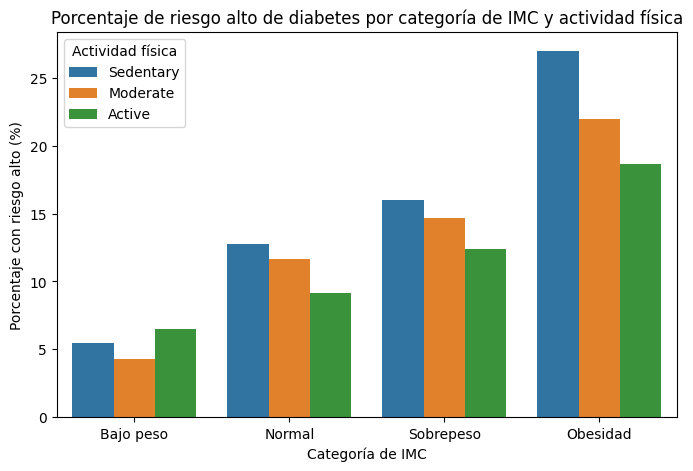

In [54]:
# gráfica de apoyo, porcentaje de riesgo alto por categoría de imc y actividad física
plt.figure(figsize=(8, 5))
sns.barplot(data=pct_high_h4, x='categoria_imc', y='pct_high', hue='physical_activity_level')
plt.xlabel('Categoría de IMC')
plt.ylabel('Porcentaje con riesgo alto (%)')
plt.title('Porcentaje de riesgo alto de diabetes por categoría de IMC y actividad física')
plt.legend(title='Actividad física')
plt.show()

Insights:

En los tres niveles de actividad física, el porcentaje de riesgo alto sube de forma consistente conforme sube la categoría de IMC. En sedentarios pasa de 5.49% (Bajo peso) a 12.76% (Normal), 16.01% (Sobrepeso) y 27.00% (Obesidad). En actividad moderada pasa de 4.26% a 11.65%, 14.64% y 21.95%. En activos pasa de 6.51% a 9.13%, 12.42% y 18.63%.

El patrón confirma lo que ya mostraba la V de Cramér: la relación IMC, riesgo se mantiene igual de clara en dirección (a más IMC, más riesgo alto) en los tres grupos, pero el salto es más pronunciado en sedentarios (de 5.49% a 27.00%, una diferencia de 21.51 puntos) que en activos (de 6.51% a 18.63%, una diferencia de 12.12 puntos). Esto refuerza, de forma descriptiva, la idea de que la actividad física podría moderar (sin eliminar) el efecto del IMC sobre el riesgo de diabetes.

In [55]:
# prueba t de Welch, IMC de riesgo High contra riesgo Low, dentro de cada estrato de actividad física
for nivel_act in niveles_actividad:
    sub = df[df['physical_activity_level'] == nivel_act]
    imc_high_e = sub.loc[sub['diabetes_risk'] == 'High', 'bmi']
    imc_low_e = sub.loc[sub['diabetes_risk'] == 'Low', 'bmi']
    t_e, gl_e, p_e, dif_e, ic_low_e, ic_high_e, d_e = prueba_t_welch(imc_high_e, imc_low_e)
    print(f'{nivel_act}: t = {t_e:.2f}, p = {p_e:.3e}, diferencia = {dif_e:.2f}, '
          f'IC 95% = ({ic_low_e:.2f}, {ic_high_e:.2f}), d de Cohen = {d_e:.3f}')

Sedentary: t = 17.96, p = 2.565e-66, diferencia = 2.57, IC 95% = (2.29, 2.85), d de Cohen = 0.678
Moderate: t = 14.31, p = 2.290e-42, diferencia = 2.17, IC 95% = (1.87, 2.47), d de Cohen = 0.622
Active: t = 9.01, p = 2.873e-18, diferencia = 1.54, IC 95% = (1.20, 1.87), d de Cohen = 0.463


Insights:

Usando el IMC como variable continua, se compara con una prueba t de Welch el IMC de los pacientes de riesgo High contra los de riesgo Low dentro de cada nivel de actividad física:

- Sedentarios: t = 17.96, p = 2.57e-66, diferencia de 2.57 puntos (IC 95% de 2.29 a 2.85), d de Cohen = 0.678 (mediano).
- Actividad moderada: t = 14.31, p = 2.29e-42, diferencia de 2.17 puntos (IC 95% de 1.87 a 2.47), d de Cohen = 0.622 (mediano).
- Activos: t = 9.01, p = 2.87e-18, diferencia de 1.54 puntos (IC 95% de 1.20 a 1.87), d de Cohen = 0.463 (pequeño, cercano a mediano).

En los tres estratos se rechaza H0: el IMC de los pacientes de riesgo alto es mayor que el de riesgo bajo, sin importar el nivel de actividad física. Además, la diferencia se va haciendo más chica conforme aumenta la actividad física (de 2.57 a 1.54 puntos, y la d de Cohen de 0.678 a 0.463), lo que coincide con lo que ya mostraba la V de Cramér. Igual que antes, es un indicio descriptivo y no una prueba formal de interacción.

### 5.6 Actividad física y riesgo dentro de cada categoría de IMC

**Objetivo:** en H3 se vio que el IMC y la actividad física están fuertemente asociados (eta cuadrada = 0.2432 y d de Cohen = 1.385 entre sedentarios y activos, el efecto más grande de todo este paso). Eso significa que parte de la asociación observada en H1 entre actividad física y riesgo de diabetes podría explicarse, al menos en parte, por el IMC: las personas sedentarias tienden a tener un IMC más alto, y un IMC más alto ya está asociado con más riesgo (H2). Para saber si la actividad física aporta algo por sí misma, más allá del IMC, se corre una prueba chi cuadrado de `physical_activity_level` contra `diabetes_risk` por separado dentro de cada `categoria_imc` (4 pruebas en total), con V de Cramér por estrato y verificación de que la frecuencia esperada mínima sea mayor o igual a 5 en cada tabla.

- H0 (por estrato): dentro de esa categoría de IMC, la actividad física y el riesgo de diabetes son independientes.
- H1 (por estrato): dentro de esa categoría de IMC, la actividad física y el riesgo de diabetes están asociados.


In [56]:
# chi cuadrado de physical_activity_level vs diabetes_risk, una prueba por categoría de imc
niveles_imc = ['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad']
resultados_h5b = []
for cat_imc in niveles_imc:
    sub = df[df['categoria_imc'] == cat_imc]
    tabla_imc = pd.crosstab(sub['physical_activity_level'], sub['diabetes_risk'])
    chi2_i, p_i, gl_i, esperado_i, v_i = prueba_chi2_cramer(tabla_imc)
    resultados_h5b.append({
        'categoria_imc': cat_imc,
        'n': len(sub),
        'chi2': chi2_i,
        'gl': gl_i,
        'p': p_i,
        'esperado_min': esperado_i.min(),
        'V_cramer': v_i,
    })

resumen_h5b = pd.DataFrame(resultados_h5b)
resumen_h5b

,categoria_imc,n,chi2,gl,p,esperado_min,V_cramer
0,Bajo peso,1773,10.414160,4,3.400018e-02,5.389171,0.054193
1,Normal,6118,18.904342,4,8.206933e-04,127.040046,0.039306
2,Sobrepeso,2625,9.636501,4,4.701678e-02,90.697143,0.042843
3,Obesidad,4484,33.841070,4,8.032597e-07,118.918822,0.061429


In [57]:
# decisión por estrato, comparando el p valor contra alfa
resumen_h5b['rechaza_h0'] = resumen_h5b['p'] < alfa
resumen_h5b

,categoria_imc,n,chi2,gl,p,esperado_min,V_cramer,rechaza_h0
0,Bajo peso,1773,10.414160,4,3.400018e-02,5.389171,0.054193,True
1,Normal,6118,18.904342,4,8.206933e-04,127.040046,0.039306,True
2,Sobrepeso,2625,9.636501,4,4.701678e-02,90.697143,0.042843,True
3,Obesidad,4484,33.841070,4,8.032597e-07,118.918822,0.061429,True


Insights:

Frecuencia esperada mínima por estrato: Bajo peso 5.39, Normal 127.04, Sobrepeso 90.70, Obesidad 118.92. Todas superan el umbral de 5 (Bajo peso queda justo por encima, cerca del límite, porque es la categoría de IMC con menos pacientes, n = 1,773), así que se cumple el supuesto del chi cuadrado en los cuatro estratos.

- Bajo peso (n = 1,773): chi2 = 10.41, gl = 4, p = 0.0340. Se rechaza H0, pero con p cercano a alfa. V de Cramér = 0.0542, efecto casi nulo.
- Normal (n = 6,118): chi2 = 18.90, gl = 4, p = 8.21e-04. Se rechaza H0. V de Cramér = 0.0393, efecto casi nulo.
- Sobrepeso (n = 2,625): chi2 = 9.64, gl = 4, p = 0.0470. Se rechaza H0, pero con p apenas por debajo de alfa. V de Cramér = 0.0428, efecto casi nulo.
- Obesidad (n = 4,484): chi2 = 33.84, gl = 4, p = 8.03e-07. Se rechaza H0. V de Cramér = 0.0614, efecto pequeño.

Se rechaza H0 en las cuatro categorías de IMC, pero en Bajo peso y Sobrepeso el p valor queda muy cerca de 0.05, así que esos dos resultados son frágiles y se interpretan con cautela. Lo más importante es el tamaño del efecto: en los cuatro estratos la V de Cramér (entre 0.04 y 0.06) es mucho más baja que la V de 0.1229 que se obtuvo en H1 sin controlar por IMC.

In [58]:
# porcentaje de pacientes con riesgo alto (High), por actividad física dentro de cada categoría de imc
pct_high_h5b = (
    df.groupby(['categoria_imc', 'physical_activity_level'], observed=True)['diabetes_risk']
    .apply(lambda serie: (serie == 'High').mean() * 100)
    .reset_index(name='pct_high')
)
pct_high_h5b

,categoria_imc,physical_activity_level,pct_high
0,Bajo peso,Sedentary,5.494505
1,Bajo peso,Moderate,4.255319
2,Bajo peso,Active,6.513106
3,Normal,Sedentary,12.764159
4,Normal,Moderate,11.652253
5,Normal,Active,9.130752
6,Sobrepeso,Sedentary,16.008105
7,Sobrepeso,Moderate,14.636542
8,Sobrepeso,Active,12.419355
9,Obesidad,Sedentary,26.998884


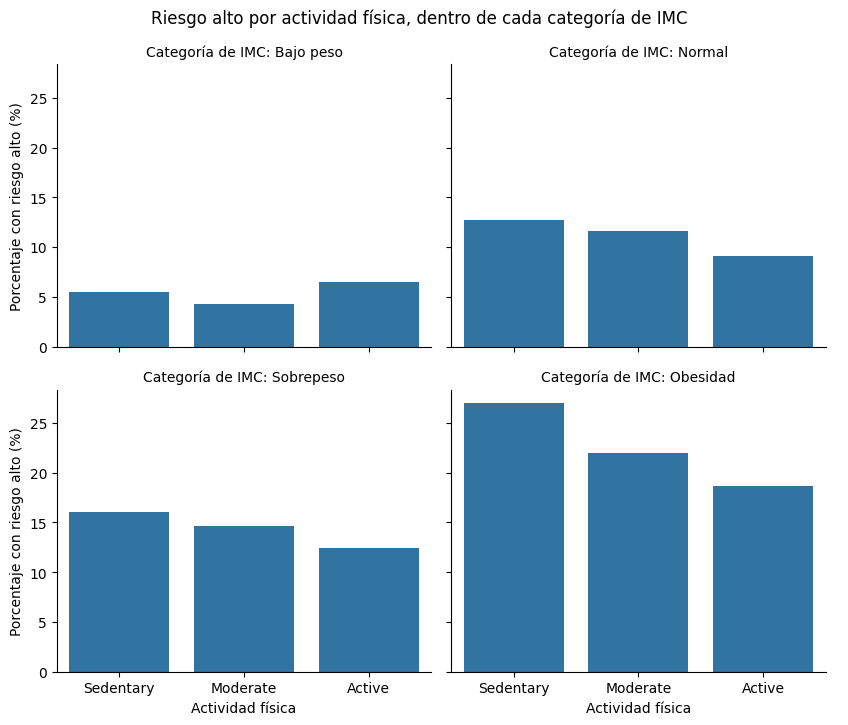

In [59]:
# gráfica de apoyo, porcentaje de riesgo alto por actividad física, separado por categoría de imc
g_h5b = sns.catplot(
    data=pct_high_h5b, x='physical_activity_level', y='pct_high',
    col='categoria_imc', kind='bar', col_wrap=2, height=3.5, aspect=1.2,
    order=niveles_actividad,
)
g_h5b.set_axis_labels('Actividad física', 'Porcentaje con riesgo alto (%)')
g_h5b.set_titles('Categoría de IMC: {col_name}')
g_h5b.figure.suptitle('Riesgo alto por actividad física, dentro de cada categoría de IMC', y=1.03)
plt.show()

Insights:

El porcentaje de riesgo alto sigue bajando conforme aumenta la actividad física dentro de cada categoría de IMC, en tres de las cuatro: en Normal pasa de 12.76% (Sedentary) a 11.65% (Moderate) y 9.13% (Active); en Sobrepeso pasa de 16.01% a 14.64% y 12.42%; en Obesidad pasa de 27.00% a 21.95% y 18.63%. En Bajo peso el patrón no es monótono: 5.49% en Sedentary, 4.26% en Moderate y 6.51% en Active, coherente con que ese estrato tiene el p valor más débil y un efecto casi nulo.

Conclusión: la actividad física sí sigue asociada con el riesgo de diabetes una vez que se controla por categoría de IMC, pero la fuerza de esa asociación baja bastante frente a la prueba sin controlar (V entre 0.04 y 0.06 dentro de cada categoría de IMC, contra V = 0.1229 en H1). Esto indica que una parte importante, aunque no toda, de la asociación entre actividad física y riesgo que se veía en H1 se explica por su relación con el IMC. La actividad física aporta algo por sí misma (sobre todo en los estratos Normal y Obesidad, que tienen los p valores más claros y concentran a la mayoría de los pacientes), pero su efecto propio es más modesto de lo que sugería la prueba sin estratificar.

### 5.7 Factores secundarios y riesgo de diabetes

**Objetivo:** Revisar si otros factores (antecedentes familiares, género, tipo de dieta y estatus de fumador) también están asociados con el riesgo de diabetes, con chi cuadrado y V de Cramér para cada uno. Para `smoking_status` se excluye la categoría `Sin dato` en esta prueba en particular, porque es un valor que se imputó por falta de información y no una categoría real de estatus de fumador; incluirla mezclaría una etiqueta de dato faltante con categorías sustantivas.

- H0 (por factor): el factor y el riesgo de diabetes son independientes.
- H1 (por factor): el factor y el riesgo de diabetes están asociados.


In [60]:
# chi cuadrado y V de Cramér para cada factor secundario
factores_h6 = ['family_history_diabetes', 'gender', 'diet_type', 'smoking_status']
resultados_h6 = []
for factor in factores_h6:
    sub = df.copy()
    if factor == 'smoking_status':
        # se excluye 'Sin dato', que representa nulos imputados y no una categoría real
        sub = sub[sub[factor] != 'Sin dato']
    tabla_factor = pd.crosstab(sub[factor], sub['diabetes_risk'])
    chi2_f, p_f, gl_f, esperado_f, v_f = prueba_chi2_cramer(tabla_factor)
    resultados_h6.append({
        'factor': factor,
        'chi2': chi2_f,
        'gl': gl_f,
        'p': p_f,
        'esperado_min': esperado_f.min(),
        'V_cramer': v_f,
    })

resumen_h6 = pd.DataFrame(resultados_h6)
resumen_h6

,factor,chi2,gl,p,esperado_min,V_cramer
0,family_history_diabetes,402.296684,2,4.389197e-88,786.600000,0.163767
1,gender,2.659808,4,6.162658e-01,22.950000,0.009416
2,diet_type,4.701813,6,5.825861e-01,42.900000,0.012519
3,smoking_status,5.342105,4,2.539611e-01,219.631264,0.013559


In [61]:
# decisión por factor, comparando el p valor contra alfa
resumen_h6['rechaza_h0'] = resumen_h6['p'] < alfa
resumen_h6

,factor,chi2,gl,p,esperado_min,V_cramer,rechaza_h0
0,family_history_diabetes,402.296684,2,4.389197e-88,786.600000,0.163767,True
1,gender,2.659808,4,6.162658e-01,22.950000,0.009416,False
2,diet_type,4.701813,6,5.825861e-01,42.900000,0.012519,False
3,smoking_status,5.342105,4,2.539611e-01,219.631264,0.013559,False


Insights:

Todas las frecuencias esperadas mínimas están muy por encima de 5 (786.6 en antecedentes familiares, 22.95 en género, que es donde está la categoría más chica, 'Other', con 153 pacientes en total, 42.9 en tipo de dieta y 219.63 en estatus de fumador), así que en ningún caso hace falta agrupar categorías ni usar una prueba exacta.

- `family_history_diabetes`: chi2 = 402.30, gl = 2, p = 4.39e-88. Se rechaza H0. V de Cramér = 0.1638, efecto pequeño a mediano. Tener antecedentes familiares de diabetes sí está asociado con el nivel de riesgo.
- `gender`: chi2 = 2.66, gl = 4, p = 0.6163. No se rechaza H0. V de Cramér = 0.0094, prácticamente nulo. No hay evidencia suficiente de asociación entre género y riesgo de diabetes.
- `diet_type`: chi2 = 4.70, gl = 6, p = 0.5826. No se rechaza H0. V de Cramér = 0.0125, prácticamente nulo.
- `smoking_status`: chi2 = 5.34, gl = 4, p = 0.2540. No se rechaza H0. V de Cramér = 0.0136, prácticamente nulo.

Solo los antecedentes familiares de diabetes muestran una asociación real con el riesgo. Género, tipo de dieta y estatus de fumador no muestran evidencia suficiente de asociación en este conjunto de datos.

### 5.8 Validación de la variable objetivo

**Objetivo:** Comprobar que la etiqueta `diabetes_risk` es coherente con dos marcadores clínicos objetivos: glucosa en ayunas (`fasting_blood_sugar`) y hemoglobina glucosilada (`hba1c_level`). Se usa el ANOVA de Welch para comparar los tres niveles de riesgo y una prueba t de Welch entre riesgo High y riesgo Low. Aunque estas variables no son normales, los tamaños de muestra son grandes, igual que en 5.3.

- H0: el promedio del marcador clínico es el mismo en los tres niveles de riesgo.
- H1: al menos un nivel de riesgo difiere de los demás en el promedio de ese marcador.


In [62]:
# ANOVA de Welch y prueba t de Welch de los marcadores clínicos por nivel de riesgo
for columna in ['fasting_blood_sugar', 'hba1c_level']:
    grupos_h7 = [df.loc[df['diabetes_risk'] == nivel, columna] for nivel in niveles_riesgo]
    for nivel, grupo in zip(niveles_riesgo, grupos_h7):
        print(f'{columna}, {nivel}: n = {len(grupo)}, media = {grupo.mean():.2f}, mediana = {grupo.median():.2f}')
    F_h7, gl1_h7, gl2_h7, p_h7 = anova_welch(grupos_h7)
    media_general_h7 = df[columna].mean()
    ss_entre_h7 = sum(len(g) * (g.mean() - media_general_h7) ** 2 for g in grupos_h7)
    eta2_h7 = ss_entre_h7 / ((df[columna] - media_general_h7) ** 2).sum()
    print(f'ANOVA de Welch {columna}: F = {F_h7:.2f}, p = {p_h7:.3e}, eta cuadrada = {eta2_h7:.4f}')
    # comparación planeada entre los extremos
    t_h7, gl_t_h7, p_t_h7, dif_h7, ic_low_h7, ic_high_h7, d_h7 = prueba_t_welch(grupos_h7[2], grupos_h7[0])
    print(f'Prueba t de Welch High contra Low: t = {t_h7:.2f}, p = {p_t_h7:.3e}, diferencia = {dif_h7:.2f}, '
          f'IC 95% = ({ic_low_h7:.2f}, {ic_high_h7:.2f}), d de Cohen = {d_h7:.3f}')
    print()

fasting_blood_sugar, Low: n = 9000, media = 148.30, mediana = 150.00
fasting_blood_sugar, Moderate: n = 3750, media = 183.32, mediana = 182.00
fasting_blood_sugar, High: n = 2250, media = 226.54, mediana = 220.00
ANOVA de Welch fasting_blood_sugar: F = 6832.95, p = 0.000e+00, eta cuadrada = 0.5469
Prueba t de Welch High contra Low: t = 96.49, p = 0.000e+00, diferencia = 78.24, IC 95% = (76.65, 79.83), d de Cohen = 2.510

hba1c_level, Low: n = 9000, media = 6.43, mediana = 6.50
hba1c_level, Moderate: n = 3750, media = 7.20, mediana = 7.20
hba1c_level, High: n = 2250, media = 8.14, mediana = 8.00
ANOVA de Welch hba1c_level: F = 6600.29, p = 0.000e+00, eta cuadrada = 0.5401
Prueba t de Welch High contra Low: t = 95.65, p = 0.000e+00, diferencia = 1.71, IC 95% = (1.67, 1.74), d de Cohen = 2.495



Insights:

`fasting_blood_sugar`: media de 148.30 en Low, 183.32 en Moderate y 226.54 en High. ANOVA de Welch F = 6832.95, p prácticamente 0, eta cuadrada = 0.5469, un tamaño de efecto grande. La prueba t de Welch entre High y Low da t = 96.49, con una diferencia de 78.24 en glucosa (IC 95% de 76.65 a 79.83) y una d de Cohen de 2.510.

`hba1c_level`: media de 6.43 en Low, 7.20 en Moderate y 8.14 en High. ANOVA de Welch F = 6600.29, p prácticamente 0, eta cuadrada = 0.5401, también un tamaño de efecto grande. La prueba t de Welch entre High y Low da t = 95.65, con una diferencia de 1.71 puntos de HbA1c (IC 95% de 1.67 a 1.74) y una d de Cohen de 2.495.

En ambos marcadores se rechaza H0 con tamaños de efecto muy grandes (eta cuadrada casi 4 veces el umbral de 0.14 y d de Cohen de más de 3 veces el umbral de 0.8). Esto confirma que la etiqueta `diabetes_risk` es coherente: refleja de forma consistente diferencias reales en glucosa en ayunas y HbA1c entre niveles de riesgo.

### Observaciones del Paso 5

**Comentario:**

Resumen de todas las pruebas de hipótesis de este paso (alfa = 0.05):

| Hipótesis | Prueba | Estadístico | p | Tamaño de efecto | Decisión |
|---|---|---|---|---|---|
| H1: actividad física y riesgo | chi cuadrado | chi2 = 453.49, gl = 4 | 7.65e-97 | V = 0.1229 (pequeño) | Se rechaza H0 |
| H2: IMC entre niveles de riesgo | ANOVA de Welch | F = 640.66 | 4.99e-249 | eta2 = 0.0853 (mediano) | Se rechaza H0 |
| H2: IMC, riesgo High contra Low | prueba t de Welch | t = 29.82 | 6.29e-172 | d = 0.739 (mediano) | Se rechaza H0 |
| H3: IMC entre niveles de actividad física | ANOVA de Welch | F = 2416.33 | prácticamente 0 | eta2 = 0.2432 (grande) | Se rechaza H0 |
| H3: IMC, sedentarios contra activos | prueba t de Welch | t = 69.28 | prácticamente 0 | d = 1.385 (grande) | Se rechaza H0 |
| H4: IMC categórico y riesgo, estrato Sedentary | chi cuadrado | chi2 = 272.85, gl = 6 | 5.33e-56 | V = 0.1660 (pequeño a mediano) | Se rechaza H0 |
| H4: IMC categórico y riesgo, estrato Moderate | chi cuadrado | chi2 = 243.75, gl = 6 | 8.87e-50 | V = 0.1569 (pequeño a mediano) | Se rechaza H0 |
| H4: IMC categórico y riesgo, estrato Active | chi cuadrado | chi2 = 152.00, gl = 6 | 2.92e-30 | V = 0.1221 (pequeño) | Se rechaza H0 |
| Actividad física y riesgo, IMC Bajo peso | chi cuadrado | chi2 = 10.41, gl = 4 | 0.0340 | V = 0.0542 (casi nulo) | Se rechaza H0 (frágil) |
| Actividad física y riesgo, IMC Normal | chi cuadrado | chi2 = 18.90, gl = 4 | 8.21e-04 | V = 0.0393 (casi nulo) | Se rechaza H0 |
| Actividad física y riesgo, IMC Sobrepeso | chi cuadrado | chi2 = 9.64, gl = 4 | 0.0470 | V = 0.0428 (casi nulo) | Se rechaza H0 (frágil) |
| Actividad física y riesgo, IMC Obesidad | chi cuadrado | chi2 = 33.84, gl = 4 | 8.03e-07 | V = 0.0614 (pequeño) | Se rechaza H0 |
| Factor: antecedentes familiares y riesgo | chi cuadrado | chi2 = 402.30, gl = 2 | 4.39e-88 | V = 0.1638 (pequeño a mediano) | Se rechaza H0 |
| Factor: género y riesgo | chi cuadrado | chi2 = 2.66, gl = 4 | 0.6163 | V = 0.0094 (nulo) | No se rechaza H0 |
| Factor: tipo de dieta y riesgo | chi cuadrado | chi2 = 4.70, gl = 6 | 0.5826 | V = 0.0125 (nulo) | No se rechaza H0 |
| Factor: estatus de fumador y riesgo | chi cuadrado | chi2 = 5.34, gl = 4 | 0.2540 | V = 0.0136 (nulo) | No se rechaza H0 |
| Validación: glucosa en ayunas por riesgo | ANOVA de Welch y prueba t de Welch | F = 6832.95, t = 96.49 | prácticamente 0 | eta2 = 0.5469, d = 2.510 (grande) | Se rechaza H0 |
| Validación: HbA1c por riesgo | ANOVA de Welch y prueba t de Welch | F = 6600.29, t = 95.65 | prácticamente 0 | eta2 = 0.5401, d = 2.495 (grande) | Se rechaza H0 |

Con esto respondemos la pregunta central del análisis: si existe asociación entre actividad física e IMC como predictores del riesgo de diabetes. La respuesta es que sí, en los dos frentes:

- La actividad física está asociada con el riesgo de diabetes (H1), aunque con un efecto pequeño.
- El IMC está asociado con el riesgo de diabetes (H2): los pacientes de riesgo alto tienen en promedio 2.98 puntos más de IMC que los de riesgo bajo (d = 0.739, efecto mediano).
- El IMC también está fuertemente asociado con la actividad física (H3): los sedentarios tienen en promedio 4.87 puntos más de IMC que los activos (d = 1.385, efecto grande, el más fuerte de todo el paso).
- La asociación entre IMC y riesgo se mantiene dentro de cada nivel de actividad física (H4), pero se hace más chica conforme aumenta la actividad: la diferencia de IMC entre riesgo High y Low baja de 2.57 puntos en sedentarios (d = 0.678) a 1.54 en activos (d = 0.463). Es un indicio descriptivo, no una prueba formal de interacción.
- Al controlar por categoría de IMC, la asociación entre actividad física y riesgo baja mucho (V entre 0.04 y 0.06 contra 0.1229 sin controlar). Es significativa en las cuatro categorías, pero en Bajo peso y Sobrepeso el p queda muy cerca de 0.05. Buena parte de la relación entre actividad física y riesgo pasa por el IMC.
- De los factores secundarios, solo los antecedentes familiares de diabetes muestran asociación con el riesgo; género, tipo de dieta y estatus de fumador no.
- La variable `diabetes_risk` queda validada: los pacientes de mayor riesgo tienen, de forma consistente, mayor glucosa en ayunas y mayor HbA1c, con tamaños de efecto muy grandes.

Como en todo este paso, se trata de asociaciones estadísticas observadas en los datos, no de relaciones de causa y efecto. Los resultados son un buen punto de partida para las recomendaciones del cierre del análisis.

## Paso 6: Insight ejecutivo y conclusiones

**Objetivo:** Traducir los hallazgos de todo el análisis en conclusiones claras y accionables, retomando la pregunta central del proyecto.

Respondemos las siguientes preguntas:

- ¿Qué problemas tenía originalmente el dataset y qué tan graves eran?
- ¿Existe una asociación significativa entre el nivel de actividad física y el IMC como predictores del riesgo de diabetes (la pregunta central del análisis)?
- ¿Qué otros factores están asociados con el riesgo, y cuáles no?
- ¿La variable objetivo `diabetes_risk` es una etiqueta confiable?
- ¿Qué se recomienda a partir de estos hallazgos, y qué limitaciones tiene el análisis?


### Análisis ejecutivo

**Calidad de datos:**

El dataset llegó razonablemente limpio: 15,000 pacientes, sin filas duplicadas ni `patient_id` repetidos, y sin sentinels en las columnas numéricas ni categóricas. Los únicos problemas fueron valores nulos en tres columnas: `alcohol_consumption` (3,788 nulos, 25.3%), `smoking_status` (472 nulos, 3.1%) e `income_bracket` (463 nulos, 3.1%). Al investigar el mecanismo de esos nulos con chi cuadrado, se encontró que los nulos de `alcohol_consumption` dependen fuertemente del género (MAR, Missing At Random): 41.3% de las mujeres tiene el dato nulo, contra 10.3% de los hombres y 17.6% de la categoría Other, mientras que no dependen del riesgo de diabetes ni de la actividad física. Los nulos de `smoking_status` e `income_bracket` no mostraron dependencia significativa con ninguna de las variables revisadas, es decir, se comportan como MCAR. En los tres casos se optó por rellenar con la categoría `'Sin dato'` en vez de imputar o eliminar filas, para no perder información y dejar visible que ese dato faltaba.

**Respuesta a la pregunta central:**

Sí existe una asociación significativa entre el nivel de actividad física y el IMC como predictores del riesgo de diabetes, confirmada con pruebas estadísticas formales en el Paso 5. El porcentaje de pacientes con riesgo alto baja de 21.0% en sedentarios a 14.4% en actividad moderada y 9.8% en activos (chi cuadrado, V de Cramér = 0.1229, efecto pequeño pero significativo). El IMC promedio sube de forma escalonada con el riesgo: 22.13 en riesgo bajo, 24.06 en moderado y 25.11 en alto (ANOVA de Welch, eta cuadrada = 0.0853, efecto mediano); con la prueba t de Welch, los pacientes de riesgo alto tienen en promedio 2.98 puntos más de IMC que los de riesgo bajo (IC 95% de 2.78 a 3.17, d de Cohen = 0.739). El IMC también sube conforme baja la actividad física: 20.72 en activos, 22.95 en actividad moderada y 25.59 en sedentarios (eta cuadrada = 0.2432); los sedentarios tienen 4.87 puntos más de IMC que los activos (d de Cohen = 1.385, el efecto más grande de todo el paso). Al estratificar en ambos sentidos, la historia se sostiene pero se matiza: la asociación entre IMC y riesgo se mantiene dentro de cada nivel de actividad física, aunque un poco más fuerte en sedentarios (V = 0.166, diferencia de IMC entre riesgo alto y bajo de 2.57 puntos) que en activos (V = 0.122, diferencia de 1.54 puntos); y al estratificar al revés, la asociación entre actividad física y riesgo dentro de cada categoría de IMC se debilita bastante frente al análisis sin controlar (V entre 0.04 y 0.06 contra V = 0.1229), y aunque es significativa en las cuatro categorías de IMC, en Bajo peso y Sobrepeso el p valor queda muy cerca de 0.05. En conjunto, esto dice que IMC y actividad física comparten buena parte de su relación con el riesgo de diabetes, pero ninguno de los dos reemplaza por completo al otro como predictor.

**Otros factores:**

La edad mostró el gradiente más marcado de todo el análisis: el riesgo alto sube de 4.1% en menores de 30 años a 10.4% en el grupo de 30 a 44, 18.7% en el grupo de 45 a 59 y 32.4% en el grupo de 60 años o más. Los antecedentes familiares de diabetes también están asociados: 19.7% de riesgo alto en pacientes con historial familiar, contra 12.5% sin historial (chi cuadrado, V de Cramér = 0.1638). En cambio, género, tipo de dieta y estatus de fumador no mostraron evidencia de asociación con el riesgo, (p mayor a 0.25 y V de Cramér cercana a 0 en los tres casos).

**Validación de la variable objetivo:**

La etiqueta `diabetes_risk` quedó validada contra dos marcadores clínicos objetivos: la glucosa en ayunas (`fasting_blood_sugar`) y la hemoglobina glucosilada (`hba1c_level`). Ambos marcadores difieren de forma clara entre los tres niveles de riesgo, con tamaños de efecto grandes (eta cuadrada = 0.5469 y 0.5401, d de Cohen de 2.510 y 2.495 entre riesgo alto y bajo). Esto confirma que la etiqueta de riesgo no es arbitraria, sino que refleja diferencias clínicas reales.

**Recomendaciones:**

- Promover la actividad física como estrategia de prevención: el salto de riesgo alto entre sedentarios y activos (21.0% contra 9.8%) es de los hallazgos más claros y más accionables del análisis.
- Reforzar el control de peso usando los puntos de corte asiáticos de la OMS para IMC (los mismos que se usaron para construir `categoria_imc`), ya que son más sensibles para población de origen indio que los puntos de corte estándar.
- Priorizar el tamizaje de diabetes en pacientes mayores de 45 años y en quienes tienen antecedentes familiares de diabetes, los dos factores no modificables con mayor asociación al riesgo.
- Diseñar campañas de prevención combinadas (actividad física más control de peso), ya que ambos factores están relacionados entre sí y con el riesgo, en vez de tratarlos como iniciativas separadas.
- No priorizar, por ahora, intervenciones basadas en género, tipo de dieta o estatus de fumador como criterios de riesgo, ya que no mostraron asociación en este análisis.

**Limitaciones:**

Este es un estudio transversal y observacional: todas las pruebas de hipótesis muestran asociación, no causalidad, y los datos corresponden a un único punto en el tiempo por paciente. Hay además indicios de que el dataset podría ser sintético, lo que limita generalizar estas conclusiones a la población real de India: la variable objetivo tiene proporciones exactas de 60% Low, 25% Moderate y 15% High, y la actividad física está casi perfectamente balanceada entre sus tres categorías (34% Active, 33% Sedentary, 33% Moderate), una combinación poco probable en datos recolectados de forma natural. También quedan nulos MAR sin imputar en `alcohol_consumption` (tratados como categoría `'Sin dato'`), lo que pudo introducir algo de ruido en las pruebas que involucran esa variable. Por último, no se ajustó un modelo multivariado: todas las pruebas de este análisis evalúan un factor a la vez, así que no sabemos cuánto aporta cada variable una vez que se controla por todas las demás al mismo tiempo. Como siguiente paso natural se sugiere ajustar un modelo de regresión logística ordinal, usando `diabetes_risk` como variable dependiente ordenada, para medir el aporte de cada factor controlando por el resto.